# Stock Price Prediction

In [1]:
# ============================
# Simplified paper replication
# Strategy-embedded loss + PBWA weighting
# Using free OHLCV from yfinance
# ============================

import os
import math
import random
import numpy as np
import pandas as pd

import yfinance as yf

import torch
import torch.nn as nn
from torch.optim import Adam


## 1. Experiment setup for Reproducibility

In [2]:
# ----------------------------
# Reproducibility
# ----------------------------
def set_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seeds(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## 2. Data acquisition & ingestion (universe definition included)

In [3]:
# ----------------------------
# Universe: S&P500 tickers (free) -> Data acquisition and universe definition
# ----------------------------

def load_sp500_tickers_yf():
    t = yf.Ticker("^GSPC")
    tickers = list(t.constituents.keys()) if getattr(t, "constituents", None) else None
    if not tickers:
        raise RuntimeError("yfinance constituents not available in your version.")
    return [x.replace(".", "-") for x in tickers]

In [4]:
# ----------------------------
# Data download (OHLCV) -> data ingestion / raw data acquisition
# ----------------------------
def download_ohlcv(tickers, start="2010-01-01", end="2024-01-31", auto_adjust=False):
    """
    Returns: dict with keys Open, High, Low, Close, Volume as DataFrames [date x ticker]
    yfinance can be flaky; download in chunks.
    """
    if end is None:
        end = pd.Timestamp.today().strftime("%Y-%m-%d")

    chunks = []
    chunk_size = 100
    for i in range(0, len(tickers), chunk_size):
        chunks.append(tickers[i:i+chunk_size])

    frames = []
    for ch in chunks:
        data = yf.download(
            ch, start=start, end=end, auto_adjust=auto_adjust,
            group_by="column", threads=True, progress=False
        )
        # If multiple tickers, columns are MultiIndex: (field, ticker)
        if isinstance(data.columns, pd.MultiIndex):
            frames.append(data)
        else:
            # single ticker edge case
            data.columns = pd.MultiIndex.from_product([data.columns, ch])
            frames.append(data)

    data = pd.concat(frames, axis=1).sort_index()
    out = {}
    for field in ["Open", "High", "Low", "Close", "Volume"]:
        out[field] = data[field].copy()
    return out

In [5]:
# ----------------------------
# Main runner -> data prep / universe selection
# ----------------------------
def load_default_tickers_minimal():
    # A small, liquid starter set (expand as you like).
    tickers = [
        "AAPL","MSFT","AMZN","NVDA","GOOGL","META","BRK-B","JPM","XOM","UNH",
        "V","MA","LLY","AVGO","COST","PG","HD","ABBV","KO","PEP",
        "ADBE","CRM","WMT","CSCO","ACN","MCD","TMO","ABT","INTC","NFLX"
    ]
    return [t.replace(".", "-") for t in tickers]

## 3. Universe selection & preprocessing

In [6]:
# ----------------------------
# Liquidity filter (avg dollar volume) -> data preprocessing / universe selection
# ----------------------------
def make_universe_mask(
    data,
    tickers,
    top_n=21,
    short_w=60,        # short-term liquidity window
    long_w=252,        # long-term baseline for "becoming important"
    core_frac=0.70,    # 80% slots = absolute liquidity (stable tradability)
    min_dolv=1e6,      # minimum long-term $ volume to avoid microcap noise
    eps=1e-12,
):
    """
    Returns a boolean DataFrame mask[date, ticker] indicating whether ticker is in the tradable universe at date t.
    Causal at open: uses Close.shift(1) and Volume.shift(1) so universe at t only uses info up to t-1.

    Universe design:
      - CORE bucket: top core_n by trailing (short_w) dollar volume
      - GROWTH bucket: top growth_n by liquidity acceleration (log(dolv_short) - log(dolv_long)),
        but only if dolv_long >= min_dolv (to avoid tiny illiquid names).
    """
    close = data["Close"][tickers].shift(1)
    volu  = data["Volume"][tickers].shift(1)
    dolv1 = close * volu  # daily $ volume (lagged)

    dolv_short = dolv1.rolling(short_w, min_periods=short_w).mean()

    core_n = max(1, int(round(top_n * core_frac)))
    growth_n = max(0, top_n - core_n)

    # CORE: strongest absolute liquidity
    core_rank = dolv_short.rank(axis=1, ascending=False, method="first")
    core_mask = core_rank.le(core_n)

    if growth_n > 0:
        dolv_long = dolv1.rolling(long_w, min_periods=long_w).mean()
        # "becoming important": liquidity acceleration vs its own history
        growth_score = (np.log(dolv_short + eps) - np.log(dolv_long + eps))

        # guardrail: only consider names that are at least somewhat tradable long-term
        eligible = dolv_long.ge(min_dolv)

        growth_rank = growth_score.where(eligible).rank(axis=1, ascending=False, method="first")
        growth_mask = growth_rank.le(growth_n)
    else:
        growth_mask = core_mask & False  # all False, same shape

    mask = (core_mask | growth_mask).fillna(False)
    return mask


# ----------------------------
# Liquidity filter v2 (buffered / threshold) -> universe selection
# ----------------------------
def make_universe_mask_v2(
    data,
    tickers,
    target_n=21,
    short_w=60,
    min_dolv_short=5e6,      # minimum trailing $ volume (lagged)
    buffer_mult=1.5,         # allow more than target_n names (captures "missed" opportunities)
    cap_max_names=None,      # hard cap if you want
    eps=1e-12,
):
    """
    A more permissive liquidity universe that avoids over-pruning when len(tickers) >> target_n.

    Idea:
      - Compute trailing short_w avg dollar volume (lagged).
      - Keep ALL names above a minimum $-volume threshold (min_dolv_short),
        but also (optionally) cap the daily universe to a buffered top-K by liquidity:
          K = ceil(buffer_mult * target_n)
      - This keeps tradability, while giving the model a bigger opportunity set than a strict top-N.

    Returns mask[date, ticker] (bool).
    """
    target_n = int(max(1, target_n))
    close = data["Close"][tickers].shift(1)
    volu  = data["Volume"][tickers].shift(1)
    dolv1 = close * volu

    dolv_short = dolv1.rolling(short_w, min_periods=short_w).mean()

    eligible = dolv_short.ge(min_dolv_short)

    # Buffered cap by liquidity rank (optional)
    K = int(np.ceil(buffer_mult * target_n))
    if cap_max_names is not None:
        K = int(min(K, cap_max_names))

    if K is not None and K > 0:
        rank = dolv_short.rank(axis=1, ascending=False, method="first")
        topk = rank.le(K)
        mask = (eligible & topk).fillna(False)
    else:
        mask = eligible.fillna(False)

    return mask


## 4. Feature engineering & label construction

In [7]:
# ----------------------------
# Features (all shifted by 1 day) -> feature engineering / technical indicators
# ----------------------------
def rsi(close: pd.DataFrame, window: int = 14):
    delta = close.diff()
    up = delta.clip(lower=0)
    down = (-delta).clip(lower=0)
    roll_up = up.rolling(window, min_periods=window).mean()
    roll_down = down.rolling(window, min_periods=window).mean()
    rs = roll_up / (roll_down + 1e-12)
    return 100 - (100 / (1 + rs))

In [8]:
def make_features(data): # -> feature engineering + label construction
    """
    data: dict Open/Close/Volume DF
    returns: features panel (date x ticker x feature), labels (date x ticker)
    """
    close = data["Close"]
    open_ = data["Open"]
    volu = data["Volume"]

    # Label: open->close return for day t (what we trade)
    y = (close / open_) - 1.0

    # Basic returns for feature engineering (close-to-close)
    cc = close.pct_change()

    # Momentum / reversal
    mom20 = close / close.shift(20) - 1
    mom60 = close / close.shift(60) - 1
    mom252 = close / close.shift(252) - 1
    rev5 = close / close.shift(5) - 1

    # Volatility
    vol20 = cc.rolling(20, min_periods=20).std(ddof=0)

    # MA ratios
    ma20 = close.rolling(20, min_periods=20).mean()
    ma60 = close.rolling(60, min_periods=60).mean()
    prc_ma20 = close / (ma20 + 1e-12) - 1
    prc_ma60 = close / (ma60 + 1e-12) - 1

    # Volume z-score
    vma20 = volu.rolling(20, min_periods=20).mean()
    vsd20 = volu.rolling(20, min_periods=20).std(ddof=0)
    volz20 = (volu - vma20) / (vsd20 + 1e-12)

    # RSI
    rsi14 = rsi(close, 14) / 100.0  # scale to [0,1]

    feats = {
        "mom20": mom20,
        "mom60": mom60,
        "mom252": mom252,
        "rev5": rev5,
        "vol20": vol20,
        "prc_ma20": prc_ma20,
        "prc_ma60": prc_ma60,
        "volz20": volz20,
        "rsi14": rsi14,
    }

    # Shift ALL features by 1 day to ensure they're known at time of trading (today open)
    feats = {k: v.shift(1) for k, v in feats.items()}

    return feats, y

## 5. Dataset preparation & batching

In [9]:
# ----------------------------
# Build day-batches of sequences -> data preparation / batching,
# ----------------------------
def build_day_batches(feats_dict, y, tickers, seq_len=20, start_date=None, end_date=None, universe_mask=None, min_names=20):


    """
    For each date t, we create X: [n_stocks, seq_len, n_features], Y: [n_stocks]
    Sequences are constructed from shifted features, so they end at t (feature at t uses info up to t-1).
    """
    feat_names = list(feats_dict.keys())
    dates = y.index

    if start_date is not None:
        dates = dates[dates >= pd.to_datetime(start_date)]
    if end_date is not None:
        dates = dates[dates <= pd.to_datetime(end_date)]

    # Stack features into (date x ticker x feat)
    # We'll keep in pandas for alignment then convert per day.
    F = []
    for fn in feat_names:
        df = feats_dict[fn][tickers]
        F.append(df)
    # shape: list of DFs
    # We'll fetch rolling windows per ticker per day.
    # Efficient enough for ~200 tickers, ~3000 days.

    batches = []
    for t in dates:
        # Need seq_len rows ending at t
        idx_pos = y.index.get_loc(t)
        if idx_pos < seq_len:
            continue
        window_dates = y.index[idx_pos - seq_len + 1 : idx_pos + 1]

        # Build X for all tickers: [n, seq_len, f]
        X_list = []
        for fn in feat_names:
            X_list.append(feats_dict[fn].loc[window_dates, tickers].values[:, :])
        X = np.stack(X_list, axis=-1)  # [seq_len, n, f]
        X = np.transpose(X, (1, 0, 2)) # [n, seq_len, f]

        Y = y.loc[t, tickers].values  # [n]

        # Drop tickers with any NaNs in sequence or label
        # Drop tickers with any NaNs in sequence or label
        mask = np.isfinite(Y)
        mask &= np.isfinite(X).all(axis=(1, 2))

        # NEW: apply dynamic universe membership at date t
        if universe_mask is not None:
            um = universe_mask.loc[t, tickers].values
            um = np.asarray(um, dtype=bool)
            mask &= um

        if mask.sum() < min_names:
            continue

        # inside build_day_batches, right before append
        tks_masked = list(np.array(tickers)[mask])
        batches.append((t, X[mask], Y[mask], tks_masked))


    return batches, feat_names

## 6. Model architecture

In [10]:
# ----------------------------
# Model: LSTM -> scalar return -> model architecture
# ----------------------------
class LSTMAlpha(nn.Module):
    def __init__(self, n_features, hidden=32, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        # x: [batch=n_stocks, seq_len, n_features]
        out, _ = self.lstm(x)
        last = out[:, -1, :]          # last step
        pred = self.head(last).squeeze(-1)
        return pred

## 7. Training 

In [11]:
# ----------------------------
# Train (one day = one batch)
# Strategy-embedded objective -> training
# ----------------------------
def train_model(
    batches_train,
    batches_val,
    n_features,
    lam=0.5,                # strategy weight
    k_turn=0.1,             # turnover penalty weight
    k_conc=0.1,             # concentration penalty weight
    gamma=0.0,
    max_w=0.02,
    lr=1e-3,
    epochs=5,
    weight_mode="long",     # "long" or "long_short"
    gross_long=1.0,
    gross_short=1.0,
    hidden=64,
    num_layers=1,
    dropout=0.0,
    selection_metric="auto",    # "auto", "val_net", "val_pnl", "val_mse"
    tc_bps_proxy=10.0,
    slip_bps_proxy=5.0,
):
    """
    Trains LSTMAlpha using:
        loss = MSE - lam * PnL + k_turn * turnover + k_conc * concentration

    Notes
    -----
    - Turnover is computed in ticker-map space so it stays active even when
      today's active ticker set changes.
    - For embedded training, model selection can use a net-of-cost validation
      proxy ("val_net"), which is closer to the real backtest objective than
      raw gross PnL.
    """
    model = LSTMAlpha(
        n_features=n_features,
        hidden=hidden,
        num_layers=num_layers,
        dropout=dropout,
    ).to(DEVICE)
    opt = Adam(model.parameters(), lr=lr)

    if selection_metric == "auto":
        selection_metric = "val_mse" if lam <= 0 else "val_net"

    cost_rate_proxy = (tc_bps_proxy + slip_bps_proxy) * 1e-4
    best_state = None

    if selection_metric == "val_mse":
        best_score = np.inf
        better = lambda score: score < best_score
    else:
        best_score = -np.inf
        better = lambda score: score > best_score

    def _weights_from_pred(pred):
        # TRAINING: use method="cash" so caps are enforced without breaking gradients
        if weight_mode == "long_short":
            return pbwa_long_short_weights(
                pred,
                gamma=gamma,
                max_abs_w=max_w,
                gross_long=gross_long,
                gross_short=gross_short,
                method="cash",
            )
        return pbwa_weights(
            pred,
            gamma=gamma,
            max_w=max_w,
            method="cash",
        )

    def _turnover_vs_prev_map_torch(w, tks, prev_w_map):
        """
        Compute L1 turnover in ticker-map space:
            sum_{union of tickers} |w_t - w_{t-1}|

        - Current weights w are torch tensors (so gradients flow through current-day weights).
        - Previous weights are treated as constants (stored as floats from detached prior step).
        """
        if prev_w_map is None:
            return torch.tensor(0.0, device=w.device, dtype=w.dtype)

        curr_set = set(tks)
        turn = torch.tensor(0.0, device=w.device, dtype=w.dtype)

        for i, tk in enumerate(tks):
            prev_val = float(prev_w_map.get(tk, 0.0))
            turn = turn + torch.abs(w[i] - prev_val)

        for tk, prev_val in prev_w_map.items():
            if tk not in curr_set:
                turn = turn + torch.tensor(abs(float(prev_val)), device=w.device, dtype=w.dtype)

        return turn

    for ep in range(1, epochs + 1):
        model.train()
        prev_w_map = None
        tr_pnl = []
        tr_mse = []
        tr_turn = []
        tr_conc = []

        for (dt, X_np, Y_np, _tks) in batches_train:
            X = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
            Y = torch.tensor(Y_np, dtype=torch.float32, device=DEVICE)

            pred = model(X)
            mse = torch.mean((pred - Y) ** 2)

            w = _weights_from_pred(pred)
            pnl = torch.sum(w * Y)  # gross realized portfolio return for that day

            conc = torch.sum(w ** 2)
            turn = _turnover_vs_prev_map_torch(w, _tks, prev_w_map)

            loss = mse - lam * pnl + k_turn * turn + k_conc * conc

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            opt.step()

            w_det = w.detach().cpu().numpy()
            prev_w_map = {tk: float(wi) for tk, wi in zip(_tks, w_det)}

            tr_pnl.append(float(pnl.detach().cpu().item()))
            tr_mse.append(float(mse.detach().cpu().item()))
            tr_turn.append(float(turn.detach().cpu().item()))
            tr_conc.append(float(conc.detach().cpu().item()))

        model.eval()
        with torch.no_grad():
            val_pnl = []
            val_net = []
            val_mse = []
            val_turn = []
            val_conc = []
            prev_val_w_map = None

            for (dt, X_np, Y_np, _tks) in batches_val:
                X = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
                Y = torch.tensor(Y_np, dtype=torch.float32, device=DEVICE)

                pred = model(X)
                mse = torch.mean((pred - Y) ** 2)

                w = _weights_from_pred(pred)
                pnl = torch.sum(w * Y)
                turn = _turnover_vs_prev_map_torch(w, _tks, prev_val_w_map)
                conc = torch.sum(w ** 2)
                net_proxy = pnl - cost_rate_proxy * turn

                w_det = w.detach().cpu().numpy()
                prev_val_w_map = {tk: float(wi) for tk, wi in zip(_tks, w_det)}

                val_pnl.append(float(pnl.cpu().item()))
                val_net.append(float(net_proxy.cpu().item()))
                val_mse.append(float(mse.cpu().item()))
                val_turn.append(float(turn.cpu().item()))
                val_conc.append(float(conc.cpu().item()))

        metric_map = {
            "val_pnl": float(np.mean(val_pnl)) if len(val_pnl) else -np.inf,
            "val_net": float(np.mean(val_net)) if len(val_net) else -np.inf,
            "val_mse": float(np.mean(val_mse)) if len(val_mse) else np.inf,
        }
        current_score = metric_map[selection_metric]

        if better(current_score):
            best_score = current_score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {ep:02d} | train pnl {np.mean(tr_pnl):+.6f} | train mse {np.mean(tr_mse):.6f} "
            f"| train turn {np.mean(tr_turn):.6f} | train conc {np.mean(tr_conc):.6f} "
            f"| val pnl {np.mean(val_pnl):+.6f} | val net {np.mean(val_net):+.6f} "
            f"| val mse {np.mean(val_mse):.6f} | val turn {np.mean(val_turn):.6f} "
            f"| select={selection_metric}:{current_score:+.6f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)
    return model


## 8. Trading strategy & execution (portfolio construction + rules)

In [12]:
# ----------------------------
# PBWA weights (PyTorch) -> portfolio construction / execution logic
# ----------------------------
def _project_capped_simplex_np(u, z=1.0, cap=0.02, max_iter=100, tol=1e-12):
    """
    Project vector u onto the capped simplex:
        {w : sum(w)=z, 0<=w<=cap}

    If infeasible (cap * n < z), returns a capped best-effort vector (sum < z),
    which you can interpret as residual cash / reduced gross.
    """
    u = np.asarray(u, dtype=float)
    n = u.size

    if n == 0:
        return u.copy()

    if cap * n < z - 1e-12:
        # infeasible: cannot reach target gross under the cap
        return np.clip(u, 0.0, cap)

    lo = float(u.min() - cap)
    hi = float(u.max())

    for _ in range(max_iter):
        tau = 0.5 * (lo + hi)
        w = np.clip(u - tau, 0.0, cap)
        s = w.sum()

        if abs(s - z) <= tol:
            break

        if s > z:
            lo = tau
        else:
            hi = tau

    tau = 0.5 * (lo + hi)
    return np.clip(u - tau, 0.0, cap)


def pbwa_weights(pred, gamma=0.0, max_w=0.02, eps=1e-12, method="cash"):
    """
    Long-only PBWA weights.

    method:
      - "cash": enforce caps, do NOT renormalize upward; residual is cash
      - "project": exact capped-simplex projection (best for backtest/live)
    """
    if method not in ("cash", "project"):
        raise ValueError("method must be 'cash' or 'project'")

    # Torch path
    if torch.is_tensor(pred):
        raw = torch.relu(pred - gamma)

        if raw.sum().item() <= eps:
            return torch.zeros_like(raw)

        if method == "cash":
            w = raw / (raw.sum() + eps)
            w = torch.clamp(w, max=max_w)
            # IMPORTANT: do NOT renormalize upward
            # only guard against numerical overflow above 1
            s = w.sum()
            if s.item() > 1.0 + 1e-8:
                w = w / (s + eps)
            return w

        # method == "project"
        u = raw.detach().cpu().numpy()
        w_np = _project_capped_simplex_np(u, z=1.0, cap=max_w)
        return torch.tensor(w_np, dtype=pred.dtype, device=pred.device)

    # NumPy path
    pred_np = np.asarray(pred, dtype=float)
    raw = np.maximum(0.0, pred_np - gamma)

    if raw.sum() <= eps:
        return np.zeros_like(raw)

    if method == "cash":
        w = raw / (raw.sum() + eps)
        w = np.clip(w, 0.0, max_w)
        s = w.sum()
        if s > 1.0 + 1e-8:
            w = w / (s + eps)
        return w

    return _project_capped_simplex_np(raw, z=1.0, cap=max_w)


def pbwa_long_short_weights(
    pred,
    gamma=0.0,
    max_abs_w=0.02,
    gross_long=1.0,
    gross_short=1.0,
    eps=1e-12,
    method="cash",
):
    """
    Long-short analogue of PBWA.

    method:
      - "cash": enforce per-name caps, but allow realized gross < target if infeasible
      - "project": exact capped-simplex projection on each side
    """
    if method not in ("cash", "project"):
        raise ValueError("method must be 'cash' or 'project'")

    # Torch path
    if torch.is_tensor(pred):
        raw_long = torch.relu(pred - gamma)
        raw_short = torch.relu(-pred - gamma)

        if raw_long.sum().item() <= eps and raw_short.sum().item() <= eps:
            return torch.zeros_like(pred)

        if method == "cash":
            w_long = torch.zeros_like(pred)
            w_short = torch.zeros_like(pred)

            sL = raw_long.sum()
            sS = raw_short.sum()

            if sL.item() > eps:
                w_long = gross_long * (raw_long / (sL + eps))
            if sS.item() > eps:
                w_short = gross_short * (raw_short / (sS + eps))

            # IMPORTANT: cap and DO NOT renormalize upward
            w_long = torch.clamp(w_long, max=max_abs_w)
            w_short = torch.clamp(w_short, max=max_abs_w)

            return w_long - w_short

        # method == "project"
        uL = raw_long.detach().cpu().numpy()
        uS = raw_short.detach().cpu().numpy()

        wL_np = _project_capped_simplex_np(uL, z=gross_long, cap=max_abs_w)
        wS_np = _project_capped_simplex_np(uS, z=gross_short, cap=max_abs_w)

        w_np = wL_np - wS_np
        return torch.tensor(w_np, dtype=pred.dtype, device=pred.device)

    # NumPy path
    pred_np = np.asarray(pred, dtype=float)
    raw_long = np.maximum(0.0, pred_np - gamma)
    raw_short = np.maximum(0.0, -pred_np - gamma)

    if raw_long.sum() <= eps and raw_short.sum() <= eps:
        return np.zeros_like(pred_np)

    if method == "cash":
        w_long = np.zeros_like(pred_np)
        w_short = np.zeros_like(pred_np)

        if raw_long.sum() > eps:
            w_long = gross_long * (raw_long / (raw_long.sum() + eps))
        if raw_short.sum() > eps:
            w_short = gross_short * (raw_short / (raw_short.sum() + eps))

        w_long = np.clip(w_long, 0.0, max_abs_w)
        w_short = np.clip(w_short, 0.0, max_abs_w)

        return w_long - w_short

    wL = _project_capped_simplex_np(raw_long, z=gross_long, cap=max_abs_w)
    wS = _project_capped_simplex_np(raw_short, z=gross_short, cap=max_abs_w)
    return wL - wS

## 9. Backtesting & analytics


This notebook previously contained an earlier duplicate draft of `backtest_batches` here.

To avoid silent overrides, the **single authoritative implementation** is the code cell
immediately below in this section. Edit only that final implementation.


In [13]:
# ----------------------------
# Backtest on batches (with costs) -> evaluation/backtesting
# ----------------------------
def backtest_batches(
    model,
    batches,
    tc_bps_per_side=10.0,
    slip_bps=5.0,
    gamma=0.0,
    max_w=0.02,
    weight_mode="long",      # "long" or "long_short"
    gross_long=1.0,          # only used for long_short
    gross_short=1.0,         # only used for long_short
    weight_fn=None,          # optional custom weighting function: w = weight_fn(pred)
    tol=1e-8,
    rebalance_rule="D",      # "D" (daily) or e.g. "W-MON", "W-FRI"
    shock_consecutive_down=0,# if >0, triggers an off-cycle rebalance on the NEXT day after an observed streak
    shock_proxy_rets=None,   # optional pd.Series (date->proxy return), e.g. SPY open->close
    pred_smooth_span=None,   # int span for EMA; None disables
):
    """
    Backtest one-day batches.

    Execution model:
      - We trade at open and earn open->close returns (Y), consistent with make_features().

    Rebalance:
      - If rebalance_rule == "D": recompute weights every day.
      - If rebalance_rule == "W-MON"/"W-FRI": recompute weights only on that weekday; hold weights otherwise.
      - Optional "shock" exception: if the proxy return is negative for shock_consecutive_down days in a row,
        we force a rebalance on the NEXT day after the streak is observed (causal timing).

    Holdings:
      - Saves BOTH long and short holdings (signed weights) with a "side" column.
    """
    model.eval()
    cost_rate = (tc_bps_per_side + slip_bps) * 1e-4  # bps -> fraction

    try:
        _p0 = next(model.parameters())
        _model_device = _p0.device
        _model_dtype = _p0.dtype
    except StopIteration:
        _model_device = torch.device("cpu")
        _model_dtype = torch.float32

    def _parse_rebalance_rule(rule):
        rule = str(rule).upper().strip()
        if rule in ("D", "DAILY"):
            return ("D", None)
        if rule.startswith("W-"):
            wd = rule.split("-", 1)[1]
            map_wd = {"MON": 0, "TUE": 1, "WED": 2, "THU": 3, "FRI": 4, "SAT": 5, "SUN": 6}
            if wd not in map_wd:
                raise ValueError(f"Unknown weekly weekday in rebalance_rule={rule}")
            return ("W", map_wd[wd])
        if rule in ("W", "WEEKLY"):
            return ("W", 0)  # default Monday
        raise ValueError(f"Unsupported rebalance_rule={rule}. Use 'D' or 'W-MON'/'W-FRI' etc.")

    freq_kind, weekly_wd = _parse_rebalance_rule(rebalance_rule)

    def _is_rebalance_date(dt):
        if freq_kind == "D":
            return True
        return pd.to_datetime(dt).weekday() == weekly_wd

    def _turnover_L1(w_map, prev_map):
        if prev_map is None:
            return 0.0
        keys = set(w_map.keys()) | set(prev_map.keys())
        return float(sum(abs(w_map.get(k, 0.0) - prev_map.get(k, 0.0)) for k in keys))

    def _action_counts(w_map, prev_map):
        keys = set(w_map.keys()) | (set(prev_map.keys()) if prev_map else set())
        if not keys:
            return 0, 0, 0.0, 0.0, 0, 0

        buys_n = sells_n = 0
        buy_not = sell_not = 0.0
        for k in keys:
            dw = w_map.get(k, 0.0) - (prev_map.get(k, 0.0) if prev_map else 0.0)
            if dw > tol:
                buys_n += 1
                buy_not += dw
            elif dw < -tol:
                sells_n += 1
                sell_not += -dw
        n_long = sum(1 for v in w_map.values() if v > tol)
        n_short = sum(1 for v in w_map.values() if v < -tol)
        return buys_n, sells_n, float(buy_not), float(sell_not), int(n_long), int(n_short)

    records = []
    dates = []
    gross = []
    net = []
    turnover = []

    buys_cnt = []
    sells_cnt = []
    buy_notional = []
    sell_notional = []
    n_long_list = []
    n_short_list = []
    rebalance_flag = []

    prev_w_map = None
    target_w_map = None

    proxy = None
    if shock_proxy_rets is not None:
        proxy = shock_proxy_rets.copy()
        if not isinstance(proxy.index, pd.DatetimeIndex):
            proxy.index = pd.to_datetime(proxy.index)

    consec_down = 0
    alpha = None
    ema_pred = {}
    if pred_smooth_span is not None:
        span = max(1, int(pred_smooth_span))
        alpha = 2.0 / (span + 1.0)

    with torch.no_grad():
        for (dt, X, Y, tks) in batches:
            dt = pd.to_datetime(dt)

            if not torch.is_tensor(X):
                X = torch.tensor(X, dtype=_model_dtype, device=_model_device)
            else:
                X = X.to(device=_model_device, dtype=_model_dtype)

            if not torch.is_tensor(Y):
                Y = torch.tensor(Y, dtype=_model_dtype, device=_model_device)
            else:
                Y = Y.to(device=_model_device, dtype=_model_dtype)

            scheduled = _is_rebalance_date(dt)
            triggered = bool(shock_consecutive_down and (consec_down >= int(shock_consecutive_down)))
            do_rebalance = (target_w_map is None) or scheduled or triggered

            pred = model(X)  # [n]
            pred_np = pred.detach().cpu().numpy()
            raw_map = dict(zip(tks, pred_np))
            y_np = Y.detach().cpu().numpy()

            if alpha is not None:
                for tk, pi in zip(tks, pred_np):
                    prev = ema_pred.get(tk, pi)
                    ema_pred[tk] = alpha * float(pi) + (1.0 - alpha) * float(prev)
                signal_np = np.array([ema_pred.get(tk, float(pi)) for tk, pi in zip(tks, pred_np)], dtype=float)
            else:
                signal_np = pred_np.astype(float)

            if do_rebalance:
                sig = torch.tensor(signal_np, dtype=pred.dtype, device=pred.device)

                if weight_fn is not None:
                    w = weight_fn(sig)
                else:
                    if weight_mode == "long_short":
                        w = pbwa_long_short_weights(
                            sig,
                            gamma=gamma,
                            max_abs_w=max_w,
                            gross_long=gross_long,
                            gross_short=gross_short,
                            method="project",
                        )
                    else:
                        w = pbwa_weights(sig, gamma=gamma, max_w=max_w, method="project")

                w_np = w.detach().cpu().numpy()
                target_w_map = dict(zip(tks, w_np))
                rebalance_flag.append(1)
            else:
                w_np = np.array([target_w_map.get(tk, 0.0) for tk in tks], dtype=float)
                rebalance_flag.append(0)

            w_map = dict(zip(tks, w_np))

            g = float(np.sum(w_np * y_np))
            to = _turnover_L1(w_map, prev_w_map)
            c = cost_rate * to
            n = g - c

            for tk, wi, pi, ri in zip(tks, w_np, signal_np, y_np):
                if abs(wi) > tol:
                    records.append({
                        "date": dt,
                        "ticker": tk,
                        "weight": float(wi),
                        "abs_weight": float(abs(wi)),
                        "side": "long" if wi > 0 else "short",
                        "pred_used": float(pi),
                        "pred_raw": float(raw_map.get(tk, np.nan)),
                        "ret": float(ri),
                        "rebalanced": int(do_rebalance),
                    })

            b_n, s_n, b_not, s_not, nL, nS = _action_counts(w_map, prev_w_map)

            dates.append(dt)
            gross.append(g)
            net.append(n)
            turnover.append(to)

            buys_cnt.append(b_n)
            sells_cnt.append(s_n)
            buy_notional.append(b_not)
            sell_notional.append(s_not)
            n_long_list.append(nL)
            n_short_list.append(nS)

            prev_w_map = w_map.copy()

            # Update the shock streak AFTER today's trade. This keeps tomorrow's
            # trigger causal and prevents using day-t realized returns at day-t open.
            if shock_consecutive_down and shock_consecutive_down > 0:
                if proxy is not None and dt in proxy.index:
                    px = float(proxy.loc[dt])
                else:
                    px = float(np.mean(y_np))
                consec_down = (consec_down + 1) if (px < 0.0) else 0
            else:
                consec_down = 0

    idx = pd.to_datetime(dates)
    sr = pd.Series(net, index=idx).sort_index()
    gr = pd.Series(gross, index=idx).sort_index()
    to = pd.Series(turnover, index=idx).sort_index()
    eq = (1 + sr.fillna(0)).cumprod()

    holdings = pd.DataFrame(records)
    if len(holdings):
        holdings = holdings.sort_values(["date", "abs_weight"], ascending=[True, False])

    return {
        "net": sr,
        "gross": gr,
        "equity": eq,
        "turnover": to,
        "holdings": holdings,
        "buys_count": pd.Series(buys_cnt, index=idx).sort_index(),
        "sells_count": pd.Series(sells_cnt, index=idx).sort_index(),
        "buy_notional": pd.Series(buy_notional, index=idx).sort_index(),
        "sell_notional": pd.Series(sell_notional, index=idx).sort_index(),
        "n_long": pd.Series(n_long_list, index=idx).sort_index(),
        "n_short": pd.Series(n_short_list, index=idx).sort_index(),
        "rebalanced": pd.Series(rebalance_flag, index=idx).sort_index(),
    }


## 10. Evaluation reporting & debugging

In [14]:
def trades_on_date(bt_out, date): # -> evaluation / reporting / debugging
    """Convenience: inspect buy/sell counts for a specific date."""
    d = pd.to_datetime(date)
    return {
        "buys_count": float(bt_out["buys_count"].loc[d]),
        "sells_count": float(bt_out["sells_count"].loc[d]),
        "buy_notional": float(bt_out["buy_notional"].loc[d]),
        "sell_notional": float(bt_out["sell_notional"].loc[d]),
        "n_long": float(bt_out["n_long"].loc[d]),
        "n_short": float(bt_out["n_short"].loc[d]),
    }

In [15]:
def average_trades(bt_out): #-> evaluation / reporting
    """Convenience: average buy/sell counts over the backtest period."""
    return {
        "avg_buys_per_day": float(bt_out["buys_count"].mean()),
        "avg_sells_per_day": float(bt_out["sells_count"].mean()),
        "avg_buy_notional_per_day": float(bt_out["buy_notional"].mean()),
        "avg_sell_notional_per_day": float(bt_out["sell_notional"].mean()),
        "avg_n_long_positions": float(bt_out["n_long"].mean()),
        "avg_n_short_positions": float(bt_out["n_short"].mean()),
    }

In [16]:
def perf_summary(daily_rets, freq=252): # -> evaluation/reporting
    r = daily_rets.dropna()
    if len(r) < 10:
        return {}
    mu = r.mean()
    sd = r.std(ddof=0)
    sharpe = (mu / (sd + 1e-12)) * np.sqrt(freq)
    eq = (1 + r).cumprod()
    peak = eq.cummax()
    dd = eq / peak - 1
    mdd = dd.min()
    cagr = eq.iloc[-1] ** (freq / len(r)) - 1
    return {
        "CAGR": float(cagr),
        "Sharpe": float(sharpe),
        "MaxDD": float(mdd),
        "AvgDailyTurnover": float(np.mean(np.abs(r*0 + 1)))  # placeholder, fill separately if desired
    }

In [17]:
def perf_block(rets, freq=252): # -> evaluation/reporting
    r = rets.dropna()
    ev = r.mean()
    vv = r.var(ddof=0)
    sharpe = (ev / (r.std(ddof=0) + 1e-12)) * np.sqrt(freq)
    eq = (1+r).cumprod()
    mdd = (eq/eq.cummax()-1).min()
    cagr = eq.iloc[-1]**(freq/len(r)) - 1
    return {"E_daily": float(ev), "V_daily": float(vv), "Sharpe": float(sharpe), "CAGR": float(cagr), "MaxDD": float(mdd)}


## 11. Performance & risk attribution

In [18]:
def alpha_beta(strat_rets, mkt_rets): #-> evaluation / performance attribution
    x = mkt_rets.align(strat_rets, join="inner")[0].values
    y = strat_rets.align(mkt_rets, join="inner")[0].values
    X = np.column_stack([np.ones_like(x), x])
    # OLS
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    alpha, beta = b[0], b[1]
    # t-stat alpha
    resid = y - X @ b
    s2 = (resid @ resid) / (len(y) - 2)
    var_b = s2 * np.linalg.inv(X.T @ X)
    se_alpha = np.sqrt(var_b[0,0])
    t_alpha = alpha / (se_alpha + 1e-12)
    return alpha, beta, t_alpha


In [19]:
def rolling_alpha_beta(strat, mkt, window=252): # -> evaluation / risk attribution
    df = pd.concat([strat, mkt], axis=1, join="inner")
    df.columns = ["s", "m"]
    alphas, betas = [], []
    idx = []

    for i in range(window, len(df)+1):
        sub = df.iloc[i-window:i]
        x = sub["m"].values
        y = sub["s"].values
        X = np.column_stack([np.ones_like(x), x])
        b = np.linalg.lstsq(X, y, rcond=None)[0]
        alpha, beta = b[0], b[1]
        idx.append(sub.index[-1])
        alphas.append(alpha * 252)   # annualize
        betas.append(beta)

    return pd.Series(alphas, index=idx, name="alpha_rolling_yr"), pd.Series(betas, index=idx, name="beta_rolling")

## 12. Experiment Driver

In [20]:
# ----------------------------
# Cached experiment inputs + full experiment driver
# ----------------------------
_EXPERIMENT_DATA_CACHE = {}

def _cacheable_tickers(tickers):
    return tuple(tickers) if tickers is not None else None

def prepare_experiment_inputs(
    start="2010-01-01",
    end="2024-12-31",
    top_n=21,
    seq_len=20,
    train_end="2017-12-31",
    val_end="2019-12-31",
    tickers=None,
    universe_mode="strict_top_n",
    universe_buffer_mult=1.5,
    universe_min_dolv_short=5e6,
):
    """
    Downloads data, builds features, constructs the dynamic universe, and returns
    pre-split batches. Results are cached so manual tuning can reuse the same
    data/universe prep across trials.
    """
    if tickers is None:
        print("No tickers provided. Using a minimal liquid default list. (Recommended: pass your own ticker list.)")
        tickers = load_default_tickers_minimal()

    base_univ = list(tickers)
    cache_key = (
        str(start), str(end),
        int(top_n), int(seq_len),
        str(train_end), str(val_end),
        tuple(base_univ),
        str(universe_mode),
        float(universe_buffer_mult),
        float(universe_min_dolv_short),
    )
    if cache_key in _EXPERIMENT_DATA_CACHE:
        return _EXPERIMENT_DATA_CACHE[cache_key]

    bench = "SPY"
    all_tickers = list(dict.fromkeys(base_univ + [bench]))

    data = download_ohlcv(all_tickers, start=start, end=end, auto_adjust=True)

    top_n = int(top_n)
    top_n = max(1, min(top_n, len(base_univ)))
    min_names = max(2, int(np.ceil(0.6 * top_n)))

    if len(base_univ) > top_n:
        if str(universe_mode).lower() in ("buffered_v2", "v2", "buffered", "threshold"):
            universe_mask = make_universe_mask_v2(
                data,
                base_univ,
                target_n=top_n,
                short_w=60,
                min_dolv_short=universe_min_dolv_short,
                buffer_mult=universe_buffer_mult,
            )
        else:
            universe_mask = make_universe_mask(
                data,
                base_univ,
                top_n=top_n,
                short_w=60,
                long_w=252,
                core_frac=0.70,
                min_dolv=1e6,
            )
    else:
        universe_mask = pd.DataFrame(True, index=data["Close"].index, columns=base_univ)

    feats, y = make_features(data)

    batches_all, feat_names = build_day_batches(
        feats,
        y,
        tickers=base_univ,
        seq_len=seq_len,
        universe_mask=universe_mask,
        min_names=min_names,
    )

    train_end_dt = pd.to_datetime(train_end)
    val_end_dt = pd.to_datetime(val_end)

    batches_train = [b for b in batches_all if pd.to_datetime(b[0]) <= train_end_dt]
    batches_val   = [b for b in batches_all if train_end_dt < pd.to_datetime(b[0]) <= val_end_dt]
    batches_test  = [b for b in batches_all if pd.to_datetime(b[0]) > val_end_dt]

    spy_rets_full = (data["Close"][["SPY"]] / data["Open"][["SPY"]] - 1.0)["SPY"]

    payload = {
        "data": data,
        "base_univ": base_univ,
        "feat_names": feat_names,
        "batches_all": batches_all,
        "batches_train": batches_train,
        "batches_val": batches_val,
        "batches_test": batches_test,
        "spy_rets_full": spy_rets_full,
        "top_n": top_n,
        "min_names": min_names,
        "universe_mask": universe_mask,
    }
    _EXPERIMENT_DATA_CACHE[cache_key] = payload
    return payload

def build_pipeline_cfg(base_cfg, tuned_params=None, overrides=None):
    """
    Merge base config with tuned parameters and optional one-off overrides.
    This is the single place where tuned values become the pipeline values.
    """
    cfg = dict(base_cfg)
    if tuned_params:
        cfg.update(dict(tuned_params))
    if overrides:
        cfg.update(dict(overrides))
    return cfg

def run_experiment(
    start="2010-01-01",
    end="2024-12-31",
    top_n=21,
    seq_len=20,
    train_end="2017-12-31",
    val_end="2019-12-31",
    gamma=0.0,
    max_w=0.02,
    tc_bps=10.0,
    slip_bps=5.0,
    epochs=6,
    lr=1e-3,
    lam_embedded=0.8,
    tickers=None,
    weight_mode="long",
    gross_long=1.0,
    gross_short=1.0,
    universe_mode="strict_top_n",
    universe_buffer_mult=1.5,
    universe_min_dolv_short=5e6,
    rebalance_rule="W-MON",
    shock_consecutive_down=None,
    pred_smooth_span=None,
    k_turn_embedded=0.05,
    k_conc_embedded=0.05,
    hidden=64,
    num_layers=1,
    dropout=0.0,
    selection_metric_base="val_mse",
    selection_metric_emb="val_net",
    return_val_backtests=False,
):
    """
    Runs the full pipeline:
    - download/build cached data inputs
    - train baseline (MSE only) and embedded (MSE - lam*PnL + penalties)
    - backtest test split
    - optionally also backtest validation split for manual tuning

    The function intentionally exposes both internal and external hyperparameters
    so that manual tuning results can flow directly into the pipeline.
    """
    prepared = prepare_experiment_inputs(
        start=start,
        end=end,
        top_n=top_n,
        seq_len=seq_len,
        train_end=train_end,
        val_end=val_end,
        tickers=tickers,
        universe_mode=universe_mode,
        universe_buffer_mult=universe_buffer_mult,
        universe_min_dolv_short=universe_min_dolv_short,
    )

    data = prepared["data"]
    base_univ = prepared["base_univ"]
    feat_names = prepared["feat_names"]
    batches_train = prepared["batches_train"]
    batches_val = prepared["batches_val"]
    batches_test = prepared["batches_test"]
    spy_rets_full = prepared["spy_rets_full"]
    top_n = prepared["top_n"]

    print(f"Train days: {len(batches_train)}, Val days: {len(batches_val)}, Test days: {len(batches_test)}")
    print(f"Features: {feat_names}")
    avg_names = np.mean([len(b[3]) for b in prepared['batches_all']]) if len(prepared['batches_all']) else 0.0
    print(f"Avg active universe size per day: {avg_names:.1f} | target top_n={top_n} | universe_mode={universe_mode}")
    print(f"Weight mode: {weight_mode} | gross_long={gross_long}, gross_short={gross_short}")
    print(f"Execution: rebalance_rule={rebalance_rule}, shock_consecutive_down={shock_consecutive_down}, pred_smooth_span={pred_smooth_span}")
    print(f"Embedded penalties: lam={lam_embedded}, k_turn={k_turn_embedded}, k_conc={k_conc_embedded}")
    print(f"Model hyperparams: hidden={hidden}, num_layers={num_layers}, dropout={dropout}, lr={lr}, epochs={epochs}")

    n_features = len(feat_names)

    print("\n=== Train baseline (MSE only) ===")
    model_base = train_model(
        batches_train,
        batches_val,
        n_features,
        lam=0.0,
        k_turn=0.0,
        k_conc=0.0,
        gamma=gamma,
        max_w=max_w,
        lr=lr,
        epochs=epochs,
        weight_mode=weight_mode,
        gross_long=gross_long,
        gross_short=gross_short,
        hidden=hidden,
        num_layers=num_layers,
        dropout=dropout,
        selection_metric=selection_metric_base,
        tc_bps_proxy=tc_bps,
        slip_bps_proxy=slip_bps,
    )

    print("\n=== Train strategy-embedded ===")
    model_emb = train_model(
        batches_train,
        batches_val,
        n_features,
        lam=lam_embedded,
        k_turn=k_turn_embedded,
        k_conc=k_conc_embedded,
        gamma=gamma,
        max_w=max_w,
        lr=lr,
        epochs=epochs,
        weight_mode=weight_mode,
        gross_long=gross_long,
        gross_short=gross_short,
        hidden=hidden,
        num_layers=num_layers,
        dropout=dropout,
        selection_metric=selection_metric_emb,
        tc_bps_proxy=tc_bps,
        slip_bps_proxy=slip_bps,
    )

    global LAST_MODEL_BASE, LAST_MODEL_EMB, LAST_RUN_DATA, LAST_RUN_UNIVERSE, LAST_FEAT_NAMES, LAST_RUN_CFG
    LAST_MODEL_BASE = model_base
    LAST_MODEL_EMB = model_emb
    LAST_RUN_DATA = data
    LAST_RUN_UNIVERSE = base_univ
    LAST_FEAT_NAMES = feat_names
    LAST_RUN_CFG = dict(
        start=start,
        end=end,
        top_n=top_n,
        seq_len=seq_len,
        train_end=train_end,
        val_end=val_end,
        gamma=gamma,
        max_w=max_w,
        tc_bps=tc_bps,
        slip_bps=slip_bps,
        epochs=epochs,
        lr=lr,
        lam_embedded=lam_embedded,
        weight_mode=weight_mode,
        gross_long=gross_long,
        gross_short=gross_short,
        universe_mode=universe_mode,
        universe_buffer_mult=universe_buffer_mult,
        universe_min_dolv_short=universe_min_dolv_short,
        rebalance_rule=rebalance_rule,
        shock_consecutive_down=shock_consecutive_down,
        pred_smooth_span=pred_smooth_span,
        k_turn_embedded=k_turn_embedded,
        k_conc_embedded=k_conc_embedded,
        hidden=hidden,
        num_layers=num_layers,
        dropout=dropout,
        tickers=list(base_univ),
    )

    bt_base = backtest_batches(
        model_base,
        batches_test,
        tc_bps_per_side=tc_bps,
        slip_bps=slip_bps,
        gamma=gamma,
        max_w=max_w,
        weight_mode=weight_mode,
        gross_long=gross_long,
        gross_short=gross_short,
        rebalance_rule=rebalance_rule,
        shock_consecutive_down=shock_consecutive_down,
        shock_proxy_rets=spy_rets_full,
        pred_smooth_span=pred_smooth_span,
    )

    bt_emb = backtest_batches(
        model_emb,
        batches_test,
        tc_bps_per_side=tc_bps,
        slip_bps=slip_bps,
        gamma=gamma,
        max_w=max_w,
        weight_mode=weight_mode,
        gross_long=gross_long,
        gross_short=gross_short,
        rebalance_rule=rebalance_rule,
        shock_consecutive_down=shock_consecutive_down,
        shock_proxy_rets=spy_rets_full,
        pred_smooth_span=pred_smooth_span,
    )

    spy = spy_rets_full.reindex(bt_base["net"].index).dropna()
    spy_eq = (1 + spy).cumprod()

    out = {
        "baseline": bt_base,
        "embedded": bt_emb,
        "spy_rets": spy,
        "spy_eq": spy_eq,
        "feat_names": feat_names,
        "universe": base_univ,
        "run_cfg": dict(LAST_RUN_CFG),
    }

    if return_val_backtests:
        val_base = backtest_batches(
            model_base,
            batches_val,
            tc_bps_per_side=tc_bps,
            slip_bps=slip_bps,
            gamma=gamma,
            max_w=max_w,
            weight_mode=weight_mode,
            gross_long=gross_long,
            gross_short=gross_short,
            rebalance_rule=rebalance_rule,
            shock_consecutive_down=shock_consecutive_down,
            shock_proxy_rets=spy_rets_full,
            pred_smooth_span=pred_smooth_span,
        )
        val_emb = backtest_batches(
            model_emb,
            batches_val,
            tc_bps_per_side=tc_bps,
            slip_bps=slip_bps,
            gamma=gamma,
            max_w=max_w,
            weight_mode=weight_mode,
            gross_long=gross_long,
            gross_short=gross_short,
            rebalance_rule=rebalance_rule,
            shock_consecutive_down=shock_consecutive_down,
            shock_proxy_rets=spy_rets_full,
            pred_smooth_span=pred_smooth_span,
        )
        out["val_backtests"] = {
            "baseline": val_base,
            "embedded": val_emb,
        }

    return out


## 13. Manual tuning & pipeline integration

This section adds a **manual, time-safe tuning workflow**.

Use it in two modes:

1. **One parameter at a time**
   - Example: tune only `lam_embedded` over a manual list of candidate values.
   - The notebook ranks candidates on the **validation split only**, saves the best value,
     and makes it reusable.

2. **Small block search**
   - For a handful of tightly interacting parameters such as
     `lam_embedded`, `gamma`, `max_w`, `top_n`, or `shock_consecutive_down`.

The tuned values are stored in `TUNED_PARAMS_STORE`, can be written to disk as JSON,
and are injected into the main pipeline through `build_pipeline_cfg(...)`.


In [22]:
# ----------------------------
# Manual tuning helpers -> tuning / pipeline integration
# ----------------------------
import json
import itertools

TUNED_PARAMS_STORE = {}
TUNING_HISTORY = {}

def _json_safe_value(v):
    if isinstance(v, (np.integer,)):
        return int(v)
    if isinstance(v, (np.floating,)):
        return float(v)
    if isinstance(v, (np.bool_,)):
        return bool(v)
    if isinstance(v, tuple):
        return list(v)
    return v

def save_tuned_params(path="manual_tuned_params.json", tuned_store=None):
    store = TUNED_PARAMS_STORE if tuned_store is None else tuned_store
    serializable = {k: _json_safe_value(v) for k, v in dict(store).items()}
    with open(path, "w", encoding="utf-8") as f:
        json.dump(serializable, f, indent=2, sort_keys=True)
    print(f"Saved tuned parameters -> {path}")
    return path

def load_tuned_params(path="manual_tuned_params.json"):
    if not os.path.exists(path):
        print(f"No tuned-parameter file found at {path}. Starting with an empty store.")
        return {}
    with open(path, "r", encoding="utf-8") as f:
        payload = json.load(f)
    print(f"Loaded tuned parameters <- {path}")
    return payload

def _bt_metrics(bt):
    ps = perf_summary(bt["net"])
    if not ps:
        return {
            "net_sharpe": -np.inf,
            "net_cagr": -np.inf,
            "maxdd_abs": np.inf,
            "avg_turnover": np.inf,
            "final_equity": np.nan,
        }
    return {
        "net_sharpe": float(ps["Sharpe"]),
        "net_cagr": float(ps["CAGR"]),
        "maxdd_abs": float(abs(ps["MaxDD"])),
        "avg_turnover": float(bt["turnover"].mean()) if "turnover" in bt else np.nan,
        "final_equity": float(bt["equity"].iloc[-1]) if len(bt["equity"]) else np.nan,
    }


def _annualized_alpha_beta(strategy_rets, benchmark_rets, periods_per_year=252):
    """
    Regress strategy returns on benchmark returns:
        strategy_t = alpha + beta * benchmark_t + eps_t

    Returns:
        alpha_annualized, beta
    """
    df = pd.concat(
        [
            pd.Series(strategy_rets).rename("y"),
            pd.Series(benchmark_rets).rename("x"),
        ],
        axis=1,
    ).dropna()

    if len(df) < 10:
        return np.nan, np.nan

    x = df["x"].astype(float).values
    y = df["y"].astype(float).values

    # If the benchmark has near-zero variance, alpha/beta regression is unstable.
    if np.std(x) < 1e-12:
        return np.nan, np.nan

    X = np.column_stack([np.ones(len(x)), x])
    coef = np.linalg.lstsq(X, y, rcond=None)[0]

    alpha_daily = float(coef[0])
    beta = float(coef[1])

    alpha_annualized = alpha_daily * periods_per_year
    return alpha_annualized, beta


def validation_selection_metrics(out):
    """
    Metrics used to rank manual tuning trials on the validation split only.

    Ranking intent:
      1) higher embedded alpha vs baseline
      2) higher embedded net Sharpe
      3) higher embedded final equity
      4) higher Sharpe lift vs baseline
      5) higher embedded CAGR
      6) lower drawdown
      7) lower turnover
    """
    if "val_backtests" not in out:
        raise ValueError("run_experiment(..., return_val_backtests=True) is required for manual tuning.")

    emb_bt = out["val_backtests"]["embedded"]
    base_bt = out["val_backtests"]["baseline"]

    emb = _bt_metrics(emb_bt)
    base = _bt_metrics(base_bt)

    alpha_vs_baseline_ann, beta_vs_baseline = _annualized_alpha_beta(
        emb_bt["net"],
        base_bt["net"],
    )

    metrics = {
        "embedded_alpha_vs_baseline_ann": alpha_vs_baseline_ann,
        "beta_vs_baseline": beta_vs_baseline,

        "embedded_net_sharpe": emb["net_sharpe"],
        "baseline_net_sharpe": base["net_sharpe"],
        "sharpe_lift_vs_baseline": emb["net_sharpe"] - base["net_sharpe"],

        "embedded_net_cagr": emb["net_cagr"],
        "baseline_net_cagr": base["net_cagr"],
        "cagr_lift_vs_baseline": emb["net_cagr"] - base["net_cagr"],

        "embedded_maxdd_abs": emb["maxdd_abs"],
        "embedded_avg_turnover": emb["avg_turnover"],
        "embedded_final_equity": emb["final_equity"],
    }
    return metrics


def rank_manual_search_results(df):
    """
    Lexicographic ranking:

      1) higher embedded alpha vs baseline (annualized)
      2) higher embedded net Sharpe
      3) higher embedded final equity
      4) higher Sharpe lift vs baseline
      5) higher embedded net CAGR
      6) lower embedded drawdown
      7) lower embedded turnover

    Why this order:
    - alpha first: prioritize unique value added beyond the baseline
    - Sharpe second: among alpha-rich candidates, prefer better risk-adjusted performance
    - final equity third: among similar alpha/Sharpe candidates, prefer more wealth creation
    - then lift/CAGR/drawdown/turnover refine the choice
    """
    df = df.copy()

    return df.sort_values(
        by=[
            "embedded_alpha_vs_baseline_ann",
            "embedded_net_sharpe",
            "embedded_final_equity",
            "sharpe_lift_vs_baseline",
            "embedded_net_cagr",
            "embedded_maxdd_abs",
            "embedded_avg_turnover",
        ],
        ascending=[False, False, False, False, False, True, True],
        na_position="last",
    ).reset_index(drop=True)


def manual_grid_search_one_param(
    base_cfg,
    param_name,
    candidate_values,
    tuned_store=None,
    save_path=None,
    verbose=True,
):
    """
    Manual one-parameter search on the validation split.
    Example:
        df, best_val, tuned_store = manual_grid_search_one_param(
            BASE_CFG, "lam_embedded", [0.0, 0.2, 0.5, 0.8, 1.2]
        )
    """
    if tuned_store is None:
        tuned_store = dict(TUNED_PARAMS_STORE)

    rows = []
    for val in candidate_values:
        trial_store = dict(tuned_store)
        trial_store[param_name] = _json_safe_value(val)

        cfg = build_pipeline_cfg(base_cfg, trial_store)
        out = run_experiment(**cfg, return_val_backtests=True)
        metrics = validation_selection_metrics(out)

        row = {"searched_param": param_name, "candidate_value": _json_safe_value(val)}
        row.update({k: _json_safe_value(v) for k, v in metrics.items()})
        rows.append(row)

        if verbose:
            print(
                f"[manual search] {param_name}={val} | "
                f"alpha={metrics['embedded_alpha_vs_baseline_ann']:.6f} | "
                f"sharpe={metrics['embedded_net_sharpe']:.4f} | "
                f"final_eq={metrics['embedded_final_equity']:.4f} | "
                f"lift={metrics['sharpe_lift_vs_baseline']:.4f} | "
                f"cagr={metrics['embedded_net_cagr']:.4f}"
            )

    df = rank_manual_search_results(pd.DataFrame(rows))
    best_value = df.iloc[0]["candidate_value"]
    tuned_store[param_name] = _json_safe_value(best_value)

    if save_path is not None:
        save_tuned_params(path=save_path, tuned_store=tuned_store)

    TUNING_HISTORY[f"one_param::{param_name}"] = df.copy()
    return df, best_value, tuned_store


def manual_grid_search_block(
    base_cfg,
    param_grid,
    tuned_store=None,
    save_path=None,
    verbose=True,
):
    """
    Small manual block search for interacting parameters.
    Keep the grid intentionally small and explicit.
    Example:
        block_grid = {
            "lam_embedded": [0.2, 0.5, 0.8],
            "gamma": [0.0, 0.002],
            "max_w": [0.02, 0.03],
        }
    """
    if tuned_store is None:
        tuned_store = dict(TUNED_PARAMS_STORE)

    names = list(param_grid.keys())
    value_lists = [list(param_grid[n]) for n in names]

    rows = []
    for values in itertools.product(*value_lists):
        trial_store = dict(tuned_store)
        for name, val in zip(names, values):
            trial_store[name] = _json_safe_value(val)

        cfg = build_pipeline_cfg(base_cfg, trial_store)
        out = run_experiment(**cfg, return_val_backtests=True)
        metrics = validation_selection_metrics(out)

        row = {name: _json_safe_value(val) for name, val in zip(names, values)}
        row.update({k: _json_safe_value(v) for k, v in metrics.items()})
        rows.append(row)

        if verbose:
            print(
                f"[block search] params={ {name: row[name] for name in names} } | "
                f"alpha={metrics['embedded_alpha_vs_baseline_ann']:.6f} | "
                f"sharpe={metrics['embedded_net_sharpe']:.4f} | "
                f"final_eq={metrics['embedded_final_equity']:.4f} | "
                f"lift={metrics['sharpe_lift_vs_baseline']:.4f}"
            )

    df = rank_manual_search_results(pd.DataFrame(rows))
    best_row = df.iloc[0]
    for name in names:
        tuned_store[name] = _json_safe_value(best_row[name])

    if save_path is not None:
        save_tuned_params(path=save_path, tuned_store=tuned_store)

    TUNING_HISTORY[f"block::{','.join(names)}"] = df.copy()
    return df, best_row[names].to_dict(), tuned_store

## 14. Testing zone (plots, observation of the performance of the model)

This section now consumes a single authoritative object, `out_ls`, built from:
1. `BASE_CFG`
2. any values loaded from `manual_tuned_params.json`
3. any values selected during the manual tuning functions above

That keeps downstream charts and diagnostics attached to the tuned pipeline rather than a disconnected manual run.


In [46]:
# Example pipeline driver with manual tuning integration.
# Start from a clean base config, optionally load tuned params from disk,
# then decide which manual searches to run.

BASE_CFG = dict(
    top_n=40,
    lam_embedded=1.6, #0.8
    gamma=0.005,
    max_w=0.02,
    seq_len=10,
    epochs=6,
    lr=1e-4,
    hidden=64,
    num_layers=1,
    dropout=0.2,
    k_turn_embedded=0.05,
    k_conc_embedded=0.1,
    weight_mode="long_short",
    gross_long=1.0,
    gross_short=1.0,
    universe_mode="buffered_v2",
    universe_buffer_mult=1.5,
    universe_min_dolv_short=5e6,
    rebalance_rule="W-FRI",
    shock_consecutive_down=4,
    pred_smooth_span=3,
)



In [24]:
# --------------------------------------------------
# Manual tuning examples (run only the ones you want)
# --------------------------------------------------

# 1) Tune a single parameter such as lambda:
lambda_table, best_lambda, TUNED_PARAMS_STORE = manual_grid_search_one_param(
     BASE_CFG,
     "lam_embedded",
     [0.6, 0.8, 1.0, 1.2, 1.4, 1.6],
     tuned_store=TUNED_PARAMS_STORE,
     save_path="manual_tuned_params.json",
 )
display(lambda_table)

No tickers provided. Using a minimal liquid default list. (Recommended: pass your own ticker list.)
Train days: 1741, Val days: 503, Test days: 1257
Features: ['mom20', 'mom60', 'mom252', 'rev5', 'vol20', 'prc_ma20', 'prc_ma60', 'volz20', 'rsi14']
Avg active universe size per day: 29.6 | target top_n=20 | universe_mode=buffered_v2
Weight mode: long_short | gross_long=1.0, gross_short=1.0
Execution: rebalance_rule=W-FRI, shock_consecutive_down=3, pred_smooth_span=None
Embedded penalties: lam=0.6, k_turn=0.05, k_conc=0.05
Model hyperparams: hidden=32, num_layers=1, dropout=0.0, lr=0.001, epochs=6

=== Train baseline (MSE only) ===
Epoch 01 | train pnl -0.000103 | train mse 0.001095 | train turn 0.241387 | train conc 0.010285 | val pnl +0.000145 | val net -0.000092 | val mse 0.000243 | val turn 0.157895 | select=val_mse:+0.000243
Epoch 02 | train pnl -0.000062 | train mse 0.000256 | train turn 0.225184 | train conc 0.010480 | val pnl +0.000114 | val net +0.000069 | val mse 0.000278 | val 

,searched_param,candidate_value,embedded_alpha_vs_baseline_ann,beta_vs_baseline,embedded_net_sharpe,baseline_net_sharpe,sharpe_lift_vs_baseline,embedded_net_cagr,baseline_net_cagr,cagr_lift_vs_baseline,embedded_maxdd_abs,embedded_avg_turnover,embedded_final_equity
0,lam_embedded,0.6,0.013913,-3.243466,0.212718,-0.064411,0.277129,0.014658,-0.001542,0.016200,0.119418,0.000000,1.029472
1,lam_embedded,1.6,0.004085,-3.620431,0.122098,-0.075256,0.197354,0.005661,-0.001042,0.006703,0.086841,0.024852,1.011332
2,lam_embedded,1.2,0.002132,-2.685166,0.214645,-0.254999,0.469644,0.014704,-0.006236,0.020940,0.117989,0.001957,1.029565
3,lam_embedded,0.8,0.001090,-0.019919,0.075477,-0.035443,0.110920,0.000994,-0.000626,0.001620,0.022553,0.002106,1.001986
4,lam_embedded,1.4,0.000931,-1.374277,0.130730,-0.132689,0.263419,0.003660,-0.002503,0.006163,0.048619,0.012875,1.007319
5,lam_embedded,1.0,-0.004881,2.297577,0.132184,0.233172,-0.100988,0.006908,0.005889,0.001019,0.101594,0.022792,1.013836


In [26]:
# --------------------------------------------------
# Manual tuning examples (run only the ones you want)
# --------------------------------------------------
TUNED_PARAMS_STORE = load_tuned_params("manual_tuned_params.json")
# 1) Tune a single parameter such as lambda:
topn_table, best_topn, TUNED_PARAMS_STORE = manual_grid_search_one_param(
     BASE_CFG,
     "top_n",
     [20, 30, 40, 45, 50],
     tuned_store=TUNED_PARAMS_STORE,
     save_path="manual_tuned_params.json",
 )
display(topn_table)

Loaded tuned parameters <- manual_tuned_params.json
No tickers provided. Using a minimal liquid default list. (Recommended: pass your own ticker list.)
Train days: 1741, Val days: 503, Test days: 1257
Features: ['mom20', 'mom60', 'mom252', 'rev5', 'vol20', 'prc_ma20', 'prc_ma60', 'volz20', 'rsi14']
Avg active universe size per day: 29.6 | target top_n=20 | universe_mode=buffered_v2
Weight mode: long_short | gross_long=1.0, gross_short=1.0
Execution: rebalance_rule=W-FRI, shock_consecutive_down=3, pred_smooth_span=None
Embedded penalties: lam=0.6, k_turn=0.1, k_conc=0.1
Model hyperparams: hidden=32, num_layers=1, dropout=0.0, lr=0.001, epochs=6

=== Train baseline (MSE only) ===
Epoch 01 | train pnl -0.000063 | train mse 0.001559 | train turn 0.240421 | train conc 0.010333 | val pnl +0.000150 | val net +0.000063 | val mse 0.000269 | val turn 0.058084 | select=val_mse:+0.000269
Epoch 02 | train pnl -0.000047 | train mse 0.000242 | train turn 0.222698 | train conc 0.010522 | val pnl +0.00

,searched_param,candidate_value,embedded_alpha_vs_baseline_ann,beta_vs_baseline,embedded_net_sharpe,baseline_net_sharpe,sharpe_lift_vs_baseline,embedded_net_cagr,baseline_net_cagr,cagr_lift_vs_baseline,embedded_maxdd_abs,embedded_avg_turnover,embedded_final_equity
0,top_n,40,0.013760,-3.542657,0.180770,0.053944,0.126826,0.009330,0.000630,0.008700,0.083650,0.021057,1.018710
1,top_n,50,0.004451,2.848786,0.228087,0.237588,-0.009501,0.015720,0.004924,0.010796,0.118548,0.000864,1.031623
2,top_n,30,0.000111,-2.540500,-0.197836,0.238939,-0.436775,-0.016452,0.005321,-0.021773,0.107627,0.017192,0.967430
3,top_n,45,-0.002235,-0.238223,-0.136108,-0.139734,0.003627,-0.001681,-0.002786,0.001105,0.017206,0.016528,0.996648
4,top_n,20,-0.016207,4.813329,-0.212718,-0.029236,-0.183482,-0.021657,-0.000522,-0.021135,0.130463,0.000000,0.957238


In [28]:
# --------------------------------------------------
# Manual tuning examples (run only the ones you want)
# --------------------------------------------------
TUNED_PARAMS_STORE = load_tuned_params("manual_tuned_params.json")
# 1) Tune a single parameter such as lambda:
topn_table, best_topn, TUNED_PARAMS_STORE = manual_grid_search_one_param(
     BASE_CFG,
     "hidden",
     [16, 32, 64],
     tuned_store=TUNED_PARAMS_STORE,
     save_path="manual_tuned_params.json",
 )
display(topn_table)

Loaded tuned parameters <- manual_tuned_params.json
No tickers provided. Using a minimal liquid default list. (Recommended: pass your own ticker list.)
Train days: 1741, Val days: 503, Test days: 1257
Features: ['mom20', 'mom60', 'mom252', 'rev5', 'vol20', 'prc_ma20', 'prc_ma60', 'volz20', 'rsi14']
Avg active universe size per day: 29.6 | target top_n=30 | universe_mode=buffered_v2
Weight mode: long_short | gross_long=1.0, gross_short=1.0
Execution: rebalance_rule=W-FRI, shock_consecutive_down=3, pred_smooth_span=None
Embedded penalties: lam=0.6, k_turn=0.1, k_conc=0.1
Model hyperparams: hidden=16, num_layers=1, dropout=0.0, lr=0.001, epochs=6

=== Train baseline (MSE only) ===
Epoch 01 | train pnl -0.000105 | train mse 0.000655 | train turn 0.257842 | train conc 0.010299 | val pnl +0.000151 | val net -0.000049 | val mse 0.000248 | val turn 0.133803 | select=val_mse:+0.000248
Epoch 02 | train pnl -0.000078 | train mse 0.000233 | train turn 0.215600 | train conc 0.010566 | val pnl +0.00

,searched_param,candidate_value,embedded_alpha_vs_baseline_ann,beta_vs_baseline,embedded_net_sharpe,baseline_net_sharpe,sharpe_lift_vs_baseline,embedded_net_cagr,baseline_net_cagr,cagr_lift_vs_baseline,embedded_maxdd_abs,embedded_avg_turnover,embedded_final_equity
0,hidden,64,0.006160,-2.691898,0.207922,-0.136171,0.344094,0.009827,-0.001982,0.011809,0.072670,0.011293,1.019712
1,hidden,32,-0.004944,-3.915703,0.059284,-0.148725,0.208010,0.001646,-0.002510,0.004156,0.110358,0.013032,1.003288
2,hidden,16,-0.005027,1.084114,-0.311029,-0.077262,-0.233766,-0.006538,-0.001345,-0.005193,0.033501,0.008724,0.986993


In [30]:
# --------------------------------------------------
# Manual tuning examples (run only the ones you want)
# --------------------------------------------------
TUNED_PARAMS_STORE = load_tuned_params("manual_tuned_params.json")
# 1) Tune a single parameter such as lambda:
shock_table, best_shock, TUNED_PARAMS_STORE = manual_grid_search_one_param(
     BASE_CFG,
     "shock_consecutive_down",
     [0, 1, 2, 3, 4, 5, 6, 7],
     tuned_store=TUNED_PARAMS_STORE,
     save_path="manual_tuned_params.json",
 )
display(shock_table)

Loaded tuned parameters <- manual_tuned_params.json
No tickers provided. Using a minimal liquid default list. (Recommended: pass your own ticker list.)
Train days: 1741, Val days: 503, Test days: 1257
Features: ['mom20', 'mom60', 'mom252', 'rev5', 'vol20', 'prc_ma20', 'prc_ma60', 'volz20', 'rsi14']
Avg active universe size per day: 29.6 | target top_n=30 | universe_mode=buffered_v2
Weight mode: long_short | gross_long=1.0, gross_short=1.0
Execution: rebalance_rule=W-FRI, shock_consecutive_down=0, pred_smooth_span=None
Embedded penalties: lam=0.6, k_turn=0.1, k_conc=0.1
Model hyperparams: hidden=64, num_layers=1, dropout=0.0, lr=0.001, epochs=6

=== Train baseline (MSE only) ===
Epoch 01 | train pnl -0.000094 | train mse 0.000765 | train turn 0.279033 | train conc 0.010465 | val pnl +0.000026 | val net -0.000157 | val mse 0.000267 | val turn 0.122343 | select=val_mse:+0.000267
Epoch 02 | train pnl -0.000082 | train mse 0.000337 | train turn 0.267143 | train conc 0.010539 | val pnl +0.00

,searched_param,candidate_value,embedded_alpha_vs_baseline_ann,beta_vs_baseline,embedded_net_sharpe,baseline_net_sharpe,sharpe_lift_vs_baseline,embedded_net_cagr,baseline_net_cagr,cagr_lift_vs_baseline,embedded_maxdd_abs,embedded_avg_turnover,embedded_final_equity
0,shock_consecutive_down,4,0.032910,-2.469643,0.212718,0.351277,-0.138558,0.014658,0.005819,0.008839,0.119418,0.000000,1.029472
1,shock_consecutive_down,7,0.026597,-2.661329,0.212718,0.177520,0.035198,0.014658,0.002993,0.011665,0.119418,0.000000,1.029472
2,shock_consecutive_down,3,0.026393,-3.982736,0.212718,0.132197,0.080521,0.014658,0.001932,0.012726,0.119418,0.000000,1.029472
3,shock_consecutive_down,6,0.025533,-4.497158,0.212496,0.142665,0.069831,0.014500,0.001612,0.012888,0.118124,0.001065,1.029152
4,shock_consecutive_down,0,0.018185,-0.109363,0.212609,-0.002517,0.215126,0.014632,-0.000105,0.014737,0.119185,0.000130,1.029419
5,shock_consecutive_down,5,0.006341,1.471706,0.212718,0.442070,-0.229352,0.014658,0.007940,0.006718,0.119418,0.000000,1.029472
6,shock_consecutive_down,1,-0.002071,2.742720,-0.213066,-0.425305,0.212239,-0.021678,-0.005977,-0.015701,0.130463,0.000076,0.957197
7,shock_consecutive_down,2,-0.018627,1.826250,-0.214535,0.015854,-0.230389,-0.021457,0.000125,-0.021582,0.128323,0.001569,0.957628


In [32]:
# --------------------------------------------------
# Manual tuning examples (run only the ones you want)
# --------------------------------------------------
TUNED_PARAMS_STORE = load_tuned_params("manual_tuned_params.json")
# 1) Tune a single parameter such as lambda:
pds_table, best_pds, TUNED_PARAMS_STORE = manual_grid_search_one_param(
     BASE_CFG,
     "pred_smooth_span",
     [None, 2, 3, 5],
     tuned_store=TUNED_PARAMS_STORE,
     save_path="manual_tuned_params.json",
 )
display(pds_table)

Loaded tuned parameters <- manual_tuned_params.json
No tickers provided. Using a minimal liquid default list. (Recommended: pass your own ticker list.)
Train days: 1741, Val days: 503, Test days: 1257
Features: ['mom20', 'mom60', 'mom252', 'rev5', 'vol20', 'prc_ma20', 'prc_ma60', 'volz20', 'rsi14']
Avg active universe size per day: 29.6 | target top_n=30 | universe_mode=buffered_v2
Weight mode: long_short | gross_long=1.0, gross_short=1.0
Execution: rebalance_rule=W-FRI, shock_consecutive_down=4, pred_smooth_span=None
Embedded penalties: lam=0.6, k_turn=0.1, k_conc=0.1
Model hyperparams: hidden=64, num_layers=1, dropout=0.0, lr=0.001, epochs=6

=== Train baseline (MSE only) ===
Epoch 01 | train pnl -0.000067 | train mse 0.000617 | train turn 0.285974 | train conc 0.010565 | val pnl +0.000003 | val net -0.000209 | val mse 0.000293 | val turn 0.141594 | select=val_mse:+0.000293
Epoch 02 | train pnl -0.000057 | train mse 0.000343 | train turn 0.266361 | train conc 0.010569 | val pnl +0.00

,searched_param,candidate_value,embedded_alpha_vs_baseline_ann,beta_vs_baseline,embedded_net_sharpe,baseline_net_sharpe,sharpe_lift_vs_baseline,embedded_net_cagr,baseline_net_cagr,cagr_lift_vs_baseline,embedded_maxdd_abs,embedded_avg_turnover,embedded_final_equity
0,pred_smooth_span,3.0,0.006404,3.444728,0.212718,0.297667,-0.084949,0.014658,0.003371,0.011287,0.119418,0.000000,1.029472
1,pred_smooth_span,2.0,-0.000403,0.306025,0.123794,0.418635,-0.294841,0.001836,0.007579,-0.005743,0.023934,0.002551,1.003668
2,pred_smooth_span,5.0,-0.000816,3.416720,0.284387,0.379936,-0.095549,0.018880,0.006428,0.012452,0.105183,0.003634,1.038039
3,pred_smooth_span,NaN,-0.011186,1.200230,-0.222596,0.112032,-0.334628,-0.008489,0.002445,-0.010934,0.058155,0.007925,0.983128


In [34]:
# --------------------------------------------------
# Manual tuning examples (run only the ones you want)
# --------------------------------------------------
TUNED_PARAMS_STORE = load_tuned_params("manual_tuned_params.json")
# 1) Tune a single parameter such as lambda:
gamma_table, best_gamma, TUNED_PARAMS_STORE = manual_grid_search_one_param(
     BASE_CFG,
     "gamma",
     [0.0, 0.001, 0.002, 0.003, 0.005,0.5],
     tuned_store=TUNED_PARAMS_STORE,
     save_path="manual_tuned_params.json",
 )
display(gamma_table)

Loaded tuned parameters <- manual_tuned_params.json
No tickers provided. Using a minimal liquid default list. (Recommended: pass your own ticker list.)
Train days: 1741, Val days: 503, Test days: 1257
Features: ['mom20', 'mom60', 'mom252', 'rev5', 'vol20', 'prc_ma20', 'prc_ma60', 'volz20', 'rsi14']
Avg active universe size per day: 29.6 | target top_n=30 | universe_mode=buffered_v2
Weight mode: long_short | gross_long=1.0, gross_short=1.0
Execution: rebalance_rule=W-FRI, shock_consecutive_down=4, pred_smooth_span=3.0
Embedded penalties: lam=0.6, k_turn=0.1, k_conc=0.1
Model hyperparams: hidden=64, num_layers=1, dropout=0.0, lr=0.001, epochs=6

=== Train baseline (MSE only) ===
Epoch 01 | train pnl -0.000062 | train mse 0.000582 | train turn 0.288660 | train conc 0.010565 | val pnl +0.000024 | val net -0.000224 | val mse 0.000265 | val turn 0.165152 | select=val_mse:+0.000265
Epoch 02 | train pnl -0.000029 | train mse 0.000333 | train turn 0.264596 | train conc 0.010625 | val pnl +0.000

,searched_param,candidate_value,embedded_alpha_vs_baseline_ann,beta_vs_baseline,embedded_net_sharpe,baseline_net_sharpe,sharpe_lift_vs_baseline,embedded_net_cagr,baseline_net_cagr,cagr_lift_vs_baseline,embedded_maxdd_abs,embedded_avg_turnover,embedded_final_equity
0,gamma,0.005,0.026135,-9.316650,0.126324,0.342307,-0.215983,0.006705,0.001770,0.004935,0.109622,0.018506,1.013429
1,gamma,0.002,0.021989,-1.897711,0.210543,0.296961,-0.086418,0.014434,0.002089,0.012345,0.119128,0.001089,1.029018
2,gamma,0.003,0.019893,-3.190147,0.199379,0.296719,-0.097341,0.011533,0.001862,0.009671,0.098613,0.004541,1.023152
3,gamma,0.001,0.010735,-2.801059,0.176095,0.025796,0.150299,0.008076,0.000295,0.007781,0.075530,0.007836,1.016185
4,gamma,0.000,0.007600,-2.262740,0.189133,-0.043985,0.233118,0.008239,-0.000993,0.009232,0.069521,0.005769,1.016513
5,gamma,0.500,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000


In [36]:
# --------------------------------------------------
# Manual tuning examples (run only the ones you want)
# --------------------------------------------------
TUNED_PARAMS_STORE = load_tuned_params("manual_tuned_params.json")
# 1) Tune a single parameter such as lambda:
max_w_table, best_max_w, TUNED_PARAMS_STORE = manual_grid_search_one_param(
     BASE_CFG,
     "max_w",
     [0.01, 0.02, 0.03, 0.04,0.5],
     tuned_store=TUNED_PARAMS_STORE,
     save_path="manual_tuned_params.json",
 )
display(max_w_table)

Loaded tuned parameters <- manual_tuned_params.json
No tickers provided. Using a minimal liquid default list. (Recommended: pass your own ticker list.)
Train days: 1741, Val days: 503, Test days: 1257
Features: ['mom20', 'mom60', 'mom252', 'rev5', 'vol20', 'prc_ma20', 'prc_ma60', 'volz20', 'rsi14']
Avg active universe size per day: 29.6 | target top_n=30 | universe_mode=buffered_v2
Weight mode: long_short | gross_long=1.0, gross_short=1.0
Execution: rebalance_rule=W-FRI, shock_consecutive_down=4, pred_smooth_span=3.0
Embedded penalties: lam=0.6, k_turn=0.1, k_conc=0.1
Model hyperparams: hidden=64, num_layers=1, dropout=0.0, lr=0.001, epochs=6

=== Train baseline (MSE only) ===
Epoch 01 | train pnl -0.000031 | train mse 0.001163 | train turn 0.115453 | train conc 0.001895 | val pnl +0.000061 | val net -0.000110 | val mse 0.000229 | val turn 0.114209 | select=val_mse:+0.000229
Epoch 02 | train pnl -0.000042 | train mse 0.000367 | train turn 0.117603 | train conc 0.001797 | val pnl +0.000

,searched_param,candidate_value,embedded_alpha_vs_baseline_ann,beta_vs_baseline,embedded_net_sharpe,baseline_net_sharpe,sharpe_lift_vs_baseline,embedded_net_cagr,baseline_net_cagr,cagr_lift_vs_baseline,embedded_maxdd_abs,embedded_avg_turnover,embedded_final_equity
0,max_w,0.02,0.033169,-25.782421,0.178705,0.405609,-0.226904,0.010872,0.000750,0.010122,0.107915,0.011220,1.021819
1,max_w,0.03,0.006159,-2.454482,0.100432,0.365367,-0.264935,0.001643,0.001765,-0.000122,0.025801,0.004082,1.003281
2,max_w,0.01,0.000000,0.000000,0.000000,0.169229,-0.169229,0.000000,0.000503,-0.000503,0.000000,0.000000,1.000000
3,max_w,0.04,-0.000019,0.002623,-1.109173,-0.530563,-0.578610,-0.000023,-0.001611,0.001587,0.000053,0.000056,0.999953
4,max_w,0.50,-0.000028,0.006129,-1.881210,-0.418030,-1.463180,-0.000032,-0.000775,0.000742,0.000067,0.000072,0.999935


In [37]:
# --------------------------------------------------
# Manual tuning examples (run only the ones you want)
# --------------------------------------------------
TUNED_PARAMS_STORE = load_tuned_params("manual_tuned_params.json")
# 1) Tune a single parameter such as lambda:
k_turn_embedded_table, best_k_turn_embedded, TUNED_PARAMS_STORE = manual_grid_search_one_param(
     BASE_CFG,
     "k_turn_embedded",
     [0.03, 0.05, 0.08, 0.10, 0.15,0.2],
     tuned_store=TUNED_PARAMS_STORE,
     save_path="manual_tuned_params.json",
 )
display(k_turn_embedded_table)

Loaded tuned parameters <- manual_tuned_params.json
No tickers provided. Using a minimal liquid default list. (Recommended: pass your own ticker list.)
Train days: 1741, Val days: 503, Test days: 1257
Features: ['mom20', 'mom60', 'mom252', 'rev5', 'vol20', 'prc_ma20', 'prc_ma60', 'volz20', 'rsi14']
Avg active universe size per day: 29.6 | target top_n=30 | universe_mode=buffered_v2
Weight mode: long_short | gross_long=1.0, gross_short=1.0
Execution: rebalance_rule=W-FRI, shock_consecutive_down=4, pred_smooth_span=3.0
Embedded penalties: lam=0.6, k_turn=0.03, k_conc=0.1
Model hyperparams: hidden=64, num_layers=1, dropout=0.0, lr=0.001, epochs=6

=== Train baseline (MSE only) ===
Epoch 01 | train pnl -0.000052 | train mse 0.000532 | train turn 0.270568 | train conc 0.007196 | val pnl +0.000099 | val net -0.000110 | val mse 0.000213 | val turn 0.139513 | select=val_mse:+0.000213
Epoch 02 | train pnl -0.000061 | train mse 0.000373 | train turn 0.233600 | train conc 0.006913 | val pnl +0.00

,searched_param,candidate_value,embedded_alpha_vs_baseline_ann,beta_vs_baseline,embedded_net_sharpe,baseline_net_sharpe,sharpe_lift_vs_baseline,embedded_net_cagr,baseline_net_cagr,cagr_lift_vs_baseline,embedded_maxdd_abs,embedded_avg_turnover,embedded_final_equity
0,k_turn_embedded,0.05,0.045040,-16.723538,0.212718,0.471634,-0.258916,0.014658,0.001599,0.013060,0.119418,0.000000,1.029472
1,k_turn_embedded,0.08,0.039303,-9.325930,0.212718,0.403319,-0.190600,0.014658,0.002247,0.012412,0.119418,0.000000,1.029472
2,k_turn_embedded,0.20,0.038111,-23.628222,0.212718,0.347134,-0.134415,0.014658,0.000839,0.013819,0.119418,0.000000,1.029472
3,k_turn_embedded,0.10,0.029735,-23.207055,0.195023,0.297207,-0.102184,0.012471,0.000608,0.011864,0.112911,0.005943,1.025048
4,k_turn_embedded,0.03,0.008614,-3.432285,0.121024,0.445656,-0.324632,0.003062,0.001495,0.001568,0.042347,0.004727,1.006122
5,k_turn_embedded,0.15,0.005468,12.871497,0.215014,0.288584,-0.073569,0.014828,0.000997,0.013831,0.118661,0.000646,1.029815


In [39]:
# --------------------------------------------------
# Manual tuning examples (run only the ones you want)
# --------------------------------------------------
TUNED_PARAMS_STORE = load_tuned_params("manual_tuned_params.json")
# 1) Tune a single parameter such as lambda:
rebalance_rule_table, best_rebalance_rule, TUNED_PARAMS_STORE = manual_grid_search_one_param(
     BASE_CFG,
     "rebalance_rule",
     ["W-MON", "W-WED", "W-FRI"],
     tuned_store=TUNED_PARAMS_STORE,
     save_path="manual_tuned_params.json",
 )
display(rebalance_rule_table)

Loaded tuned parameters <- manual_tuned_params.json
No tickers provided. Using a minimal liquid default list. (Recommended: pass your own ticker list.)
Train days: 1741, Val days: 503, Test days: 1257
Features: ['mom20', 'mom60', 'mom252', 'rev5', 'vol20', 'prc_ma20', 'prc_ma60', 'volz20', 'rsi14']
Avg active universe size per day: 29.6 | target top_n=30 | universe_mode=buffered_v2
Weight mode: long_short | gross_long=1.0, gross_short=1.0
Execution: rebalance_rule=W-MON, shock_consecutive_down=4, pred_smooth_span=3.0
Embedded penalties: lam=0.6, k_turn=0.05, k_conc=0.1
Model hyperparams: hidden=64, num_layers=1, dropout=0.0, lr=0.001, epochs=6

=== Train baseline (MSE only) ===
Epoch 01 | train pnl -0.000053 | train mse 0.001648 | train turn 0.211824 | train conc 0.006565 | val pnl +0.000094 | val net -0.000058 | val mse 0.000322 | val turn 0.101366 | select=val_mse:+0.000322
Epoch 02 | train pnl -0.000089 | train mse 0.000328 | train turn 0.206637 | train conc 0.006389 | val pnl +0.00

,searched_param,candidate_value,embedded_alpha_vs_baseline_ann,beta_vs_baseline,embedded_net_sharpe,baseline_net_sharpe,sharpe_lift_vs_baseline,embedded_net_cagr,baseline_net_cagr,cagr_lift_vs_baseline,embedded_maxdd_abs,embedded_avg_turnover,embedded_final_equity
0,rebalance_rule,W-MON,0.032422,-13.277915,0.207954,0.553870,-0.345916,0.010681,0.001505,0.009176,0.084167,0.001549,1.021433
1,rebalance_rule,W-FRI,0.031960,-8.857552,0.216591,0.205984,0.010607,0.014984,0.001489,0.013495,0.119418,0.000086,1.030131
2,rebalance_rule,W-WED,0.015539,-9.565314,0.227324,0.053547,0.173777,0.012219,0.000151,0.012068,0.087118,0.007729,1.024537


In [40]:
# --------------------------------------------------
# Manual tuning examples (run only the ones you want)
# --------------------------------------------------
TUNED_PARAMS_STORE = load_tuned_params("manual_tuned_params.json")
# 1) Tune a single parameter such as lambda:
k_conc_embedded_table, best_k_conc_embedded, TUNED_PARAMS_STORE = manual_grid_search_one_param(
     BASE_CFG,
     "k_conc_embedded",
     [0.0, 0.03, 0.05, 0.08, 0.1, 0.2],
     tuned_store=TUNED_PARAMS_STORE,
     save_path="manual_tuned_params.json",
 )
display(k_conc_embedded_table)

Loaded tuned parameters <- manual_tuned_params.json
No tickers provided. Using a minimal liquid default list. (Recommended: pass your own ticker list.)
Train days: 1741, Val days: 503, Test days: 1257
Features: ['mom20', 'mom60', 'mom252', 'rev5', 'vol20', 'prc_ma20', 'prc_ma60', 'volz20', 'rsi14']
Avg active universe size per day: 29.6 | target top_n=30 | universe_mode=buffered_v2
Weight mode: long_short | gross_long=1.0, gross_short=1.0
Execution: rebalance_rule=W-MON, shock_consecutive_down=4, pred_smooth_span=3.0
Embedded penalties: lam=0.6, k_turn=0.05, k_conc=0.0
Model hyperparams: hidden=64, num_layers=1, dropout=0.0, lr=0.001, epochs=6

=== Train baseline (MSE only) ===
Epoch 01 | train pnl +0.000016 | train mse 0.000722 | train turn 0.257959 | train conc 0.007234 | val pnl +0.000043 | val net -0.000152 | val mse 0.000277 | val turn 0.130034 | select=val_mse:+0.000277
Epoch 02 | train pnl -0.000088 | train mse 0.000333 | train turn 0.215448 | train conc 0.006601 | val pnl +0.00

,searched_param,candidate_value,embedded_alpha_vs_baseline_ann,beta_vs_baseline,embedded_net_sharpe,baseline_net_sharpe,sharpe_lift_vs_baseline,embedded_net_cagr,baseline_net_cagr,cagr_lift_vs_baseline,embedded_maxdd_abs,embedded_avg_turnover,embedded_final_equity
0,k_conc_embedded,0.00,0.035344,-7.076276,0.208948,0.357132,-0.148184,0.014312,0.002448,0.011863,0.119259,0.000661,1.028770
1,k_conc_embedded,0.10,0.034682,-14.690522,0.207008,0.504153,-0.297145,0.013408,0.001236,0.012173,0.112747,0.006168,1.026942
2,k_conc_embedded,0.05,0.011966,0.308603,0.193100,0.800547,-0.607447,0.010830,0.003542,0.007288,0.095447,0.001315,1.021733
3,k_conc_embedded,0.03,-0.003024,8.128596,0.212718,0.875948,-0.663230,0.014658,0.002613,0.012045,0.119418,0.000000,1.029472
4,k_conc_embedded,0.20,-0.008830,3.262174,0.178740,0.859422,-0.680683,0.006829,0.005076,0.001752,0.057644,0.010273,1.013676
5,k_conc_embedded,0.08,-0.011543,7.364925,0.212718,0.803211,-0.590493,0.014658,0.004037,0.010621,0.119418,0.000000,1.029472


In [41]:
# --------------------------------------------------
# Manual tuning examples (run only the ones you want)
# --------------------------------------------------
TUNED_PARAMS_STORE = load_tuned_params("manual_tuned_params.json")
# 1) Tune a single parameter such as lambda:
lr_table, best_lr, TUNED_PARAMS_STORE = manual_grid_search_one_param(
     BASE_CFG,
     "lr",
     [1e-6, 1e-5, 3e-4, 1e-3, 3e-3],
     tuned_store=TUNED_PARAMS_STORE,
     save_path="manual_tuned_params.json",
 )
display(lr_table)

Loaded tuned parameters <- manual_tuned_params.json
No tickers provided. Using a minimal liquid default list. (Recommended: pass your own ticker list.)
Train days: 1741, Val days: 503, Test days: 1257
Features: ['mom20', 'mom60', 'mom252', 'rev5', 'vol20', 'prc_ma20', 'prc_ma60', 'volz20', 'rsi14']
Avg active universe size per day: 29.6 | target top_n=30 | universe_mode=buffered_v2
Weight mode: long_short | gross_long=1.0, gross_short=1.0
Execution: rebalance_rule=W-MON, shock_consecutive_down=4, pred_smooth_span=3.0
Embedded penalties: lam=0.6, k_turn=0.05, k_conc=0.0
Model hyperparams: hidden=64, num_layers=1, dropout=0.0, lr=1e-06, epochs=6

=== Train baseline (MSE only) ===
Epoch 01 | train pnl -0.000179 | train mse 0.037500 | train turn 0.097009 | train conc 0.010018 | val pnl -0.000144 | val net -0.000300 | val mse 0.020613 | val turn 0.104017 | select=val_mse:+0.020613
Epoch 02 | train pnl -0.000138 | train mse 0.014404 | train turn 0.123270 | train conc 0.009752 | val pnl -0.00

,searched_param,candidate_value,embedded_alpha_vs_baseline_ann,beta_vs_baseline,embedded_net_sharpe,baseline_net_sharpe,sharpe_lift_vs_baseline,embedded_net_cagr,baseline_net_cagr,cagr_lift_vs_baseline,embedded_maxdd_abs,embedded_avg_turnover,embedded_final_equity
0,lr,0.001000,0.000000,0.000000,0.000000,0.554929,-0.554929,0.000000,0.001825,-0.001825,0.000000,0.000000,1.000000
1,lr,0.000010,-0.008697,-1.539472,-0.066556,-0.660313,0.593757,-0.005973,-0.002995,-0.002979,0.097620,0.027761,0.988112
2,lr,0.000300,-0.010383,5.814357,0.209534,0.761815,-0.552281,0.014374,0.004862,0.009511,0.119347,0.000201,1.028896
3,lr,0.000001,-0.045558,-0.851581,-0.546871,-0.431900,-0.114971,-0.039968,-0.008644,-0.031324,0.124779,0.068607,0.921810
4,lr,0.003000,NaN,NaN,0.212718,0.000000,0.212718,0.014658,0.000000,0.014658,0.119418,0.000000,1.029472


In [43]:
# --------------------------------------------------
# Manual tuning examples (run only the ones you want)
# --------------------------------------------------
TUNED_PARAMS_STORE = load_tuned_params("manual_tuned_params.json")
# 1) Tune a single parameter such as lambda:
seq_len_table, best_seq_len, TUNED_PARAMS_STORE = manual_grid_search_one_param(
     BASE_CFG,
     "seq_len",
     [10, 20, 30, 40],
     tuned_store=TUNED_PARAMS_STORE,
     save_path="manual_tuned_params.json",
 )
display(seq_len_table)

Loaded tuned parameters <- manual_tuned_params.json
No tickers provided. Using a minimal liquid default list. (Recommended: pass your own ticker list.)
Train days: 1751, Val days: 503, Test days: 1257
Features: ['mom20', 'mom60', 'mom252', 'rev5', 'vol20', 'prc_ma20', 'prc_ma60', 'volz20', 'rsi14']
Avg active universe size per day: 29.6 | target top_n=30 | universe_mode=buffered_v2
Weight mode: long_short | gross_long=1.0, gross_short=1.0
Execution: rebalance_rule=W-MON, shock_consecutive_down=4, pred_smooth_span=3.0
Embedded penalties: lam=0.6, k_turn=0.05, k_conc=0.0
Model hyperparams: hidden=64, num_layers=1, dropout=0.0, lr=0.001, epochs=6

=== Train baseline (MSE only) ===
Epoch 01 | train pnl -0.000006 | train mse 0.000690 | train turn 0.271040 | train conc 0.007114 | val pnl +0.000045 | val net -0.000142 | val mse 0.000222 | val turn 0.124700 | select=val_mse:+0.000222
Epoch 02 | train pnl -0.000054 | train mse 0.000357 | train turn 0.237214 | train conc 0.007067 | val pnl +0.00

,searched_param,candidate_value,embedded_alpha_vs_baseline_ann,beta_vs_baseline,embedded_net_sharpe,baseline_net_sharpe,sharpe_lift_vs_baseline,embedded_net_cagr,baseline_net_cagr,cagr_lift_vs_baseline,embedded_maxdd_abs,embedded_avg_turnover,embedded_final_equity
0,seq_len,10,0.034575,-8.288845,0.212718,0.308528,-0.095810,0.014658,0.001954,0.012704,0.119418,0.000000,1.029472
1,seq_len,30,0.030966,-4.798209,0.212718,0.641334,-0.428616,0.014658,0.002650,0.012008,0.119418,0.000000,1.029472
2,seq_len,40,-0.011129,7.014754,0.212718,0.892927,-0.680208,0.014658,0.004182,0.010476,0.119418,0.000000,1.029472
3,seq_len,20,-0.013826,3.799565,0.101083,0.855349,-0.754267,0.003168,0.004665,-0.001496,0.060246,0.005669,1.006334


In [45]:
# --------------------------------------------------
# Manual tuning examples (run only the ones you want)
# --------------------------------------------------
TUNED_PARAMS_STORE = load_tuned_params("manual_tuned_params.json")
# 1) Tune a single parameter such as lambda:
k_turn_embedded_table, best_k_turn_embedded, TUNED_PARAMS_STORE = manual_grid_search_one_param(
     BASE_CFG,
     "dropout",
     [0.0, 0.1, 0.2],
     tuned_store=TUNED_PARAMS_STORE,
     save_path="manual_tuned_params.json",
 )
display(k_turn_embedded_table)

Loaded tuned parameters <- manual_tuned_params.json
No tickers provided. Using a minimal liquid default list. (Recommended: pass your own ticker list.)
Train days: 1751, Val days: 503, Test days: 1257
Features: ['mom20', 'mom60', 'mom252', 'rev5', 'vol20', 'prc_ma20', 'prc_ma60', 'volz20', 'rsi14']
Avg active universe size per day: 29.6 | target top_n=30 | universe_mode=buffered_v2
Weight mode: long_short | gross_long=1.0, gross_short=1.0
Execution: rebalance_rule=W-MON, shock_consecutive_down=4, pred_smooth_span=3.0
Embedded penalties: lam=0.6, k_turn=0.05, k_conc=0.0
Model hyperparams: hidden=64, num_layers=1, dropout=0.0, lr=0.001, epochs=6

=== Train baseline (MSE only) ===
Epoch 01 | train pnl -0.000075 | train mse 0.000884 | train turn 0.230944 | train conc 0.006975 | val pnl +0.000027 | val net -0.000096 | val mse 0.000434 | val turn 0.081740 | select=val_mse:+0.000434
Epoch 02 | train pnl -0.000045 | train mse 0.000307 | train turn 0.215937 | train conc 0.006549 | val pnl +0.00

,searched_param,candidate_value,embedded_alpha_vs_baseline_ann,beta_vs_baseline,embedded_net_sharpe,baseline_net_sharpe,sharpe_lift_vs_baseline,embedded_net_cagr,baseline_net_cagr,cagr_lift_vs_baseline,embedded_maxdd_abs,embedded_avg_turnover,embedded_final_equity
0,dropout,0.2,0.037309,-7.871453,0.212718,0.553712,-0.340994,0.014658,0.002418,0.012241,0.119418,0.0,1.029472
1,dropout,0.1,0.016323,-6.297404,0.212718,-0.082895,0.295613,0.014658,-0.000309,0.014967,0.119418,0.0,1.029472
2,dropout,0.0,-0.013830,8.301756,0.212718,0.765616,-0.552897,0.014658,0.003856,0.010802,0.119418,0.0,1.029472


In [47]:
# --------------------------------------------------
# Manual tuning examples (run only the ones you want)
# --------------------------------------------------
TUNED_PARAMS_STORE = load_tuned_params("manual_tuned_params.json")
# 1) Tune a single parameter such as lambda:
num_layers_table, best_num_layers, TUNED_PARAMS_STORE = manual_grid_search_one_param(
     BASE_CFG,
     "num_layers",
     [1, 2],
     tuned_store=TUNED_PARAMS_STORE,
     save_path="manual_tuned_params.json",
 )
display(num_layers_table)

Loaded tuned parameters <- manual_tuned_params.json
No tickers provided. Using a minimal liquid default list. (Recommended: pass your own ticker list.)
Train days: 1751, Val days: 503, Test days: 1257
Features: ['mom20', 'mom60', 'mom252', 'rev5', 'vol20', 'prc_ma20', 'prc_ma60', 'volz20', 'rsi14']
Avg active universe size per day: 29.6 | target top_n=30 | universe_mode=buffered_v2
Weight mode: long_short | gross_long=1.0, gross_short=1.0
Execution: rebalance_rule=W-MON, shock_consecutive_down=4, pred_smooth_span=3.0
Embedded penalties: lam=0.6, k_turn=0.05, k_conc=0.0
Model hyperparams: hidden=64, num_layers=1, dropout=0.2, lr=0.001, epochs=6

=== Train baseline (MSE only) ===
Epoch 01 | train pnl -0.000094 | train mse 0.000824 | train turn 0.241627 | train conc 0.007061 | val pnl +0.000039 | val net -0.000145 | val mse 0.000216 | val turn 0.122834 | select=val_mse:+0.000216
Epoch 02 | train pnl -0.000068 | train mse 0.000345 | train turn 0.233204 | train conc 0.006872 | val pnl +0.00

,searched_param,candidate_value,embedded_alpha_vs_baseline_ann,beta_vs_baseline,embedded_net_sharpe,baseline_net_sharpe,sharpe_lift_vs_baseline,embedded_net_cagr,baseline_net_cagr,cagr_lift_vs_baseline,embedded_maxdd_abs,embedded_avg_turnover,embedded_final_equity
0,num_layers,1,0.035326,-8.268025,0.212771,0.358616,-0.145845,0.014663,0.002053,0.012610,0.119418,0.000008,1.029481
1,num_layers,2,-0.018284,12.281561,0.212718,0.761679,-0.548961,0.014658,0.002970,0.011689,0.119418,0.000000,1.029472


In [48]:

TUNED_PARAMS_STORE = load_tuned_params("manual_tuned_params.json")


# Build the single authoritative pipeline configuration from base + tuned params.
PIPELINE_CFG = build_pipeline_cfg(BASE_CFG, TUNED_PARAMS_STORE)


Loaded tuned parameters <- manual_tuned_params.json


In [53]:

print("Pipeline configuration actually used by run_experiment:")
display(pd.Series({k: v for k, v in PIPELINE_CFG.items()}))

#out_ls = run_experiment(**PIPELINE_CFG)
out_ls = run_experiment(**BASE_CFG)

print("Baseline final equity:", out_ls["baseline"]["equity"].iloc[-1])
print("Embedded final equity:", out_ls["embedded"]["equity"].iloc[-1])

Pipeline configuration actually used by run_experiment:


top_n                               40
lam_embedded                       0.6
gamma                            0.005
max_w                             0.02
seq_len                             10
epochs                               6
lr                               0.001
hidden                              64
num_layers                           1
dropout                            0.2
k_turn_embedded                   0.05
k_conc_embedded                    0.0
weight_mode                 long_short
gross_long                         1.0
gross_short                        1.0
universe_mode              buffered_v2
universe_buffer_mult               1.5
universe_min_dolv_short      5000000.0
rebalance_rule                   W-MON
shock_consecutive_down               4
pred_smooth_span                   3.0
dtype: object

No tickers provided. Using a minimal liquid default list. (Recommended: pass your own ticker list.)
Train days: 1751, Val days: 503, Test days: 1257
Features: ['mom20', 'mom60', 'mom252', 'rev5', 'vol20', 'prc_ma20', 'prc_ma60', 'volz20', 'rsi14']
Avg active universe size per day: 29.6 | target top_n=30 | universe_mode=buffered_v2
Weight mode: long_short | gross_long=1.0, gross_short=1.0
Execution: rebalance_rule=W-FRI, shock_consecutive_down=4, pred_smooth_span=3
Embedded penalties: lam=1.6, k_turn=0.05, k_conc=0.1
Model hyperparams: hidden=64, num_layers=1, dropout=0.2, lr=0.0001, epochs=6

=== Train baseline (MSE only) ===
Epoch 01 | train pnl -0.000073 | train mse 0.004455 | train turn 0.230129 | train conc 0.007525 | val pnl -0.000083 | val net -0.000342 | val mse 0.000329 | val turn 0.172948 | select=val_mse:+0.000329
Epoch 02 | train pnl -0.000048 | train mse 0.000280 | train turn 0.188449 | train conc 0.005997 | val pnl +0.000009 | val net -0.000195 | val mse 0.000308 | val tur

In [54]:
print("Baseline final equity:", out_ls["baseline"]["equity"].iloc[-1])
print("Baseline final equity:", out_ls["embedded"]["equity"].iloc[-1])
print("Embedded final gross:", out_ls["embedded"]["gross"].iloc[-1])


Baseline final equity: 0.985035291122474
Baseline final equity: 1.2074898528915117
Embedded final gross: -0.0017345984334631932


In [55]:
print("Avg turnover baseline:", out_ls["baseline"]["turnover"].mean())
print("Avg turnover embedded:", out_ls["embedded"]["turnover"].mean())

# If you stored weights: out["baseline"]["weights"] etc. If not, approximate cash as near-zero returns:
cash_like_embedded = (out_ls["embedded"]["gross"].abs() < 1e-8).mean()
print("Embedded ~cash days (gross≈0):", cash_like_embedded)


Avg turnover baseline: 0.01073452810384185
Avg turnover embedded: 0.017899177423933953
Embedded ~cash days (gross≈0): 0.0


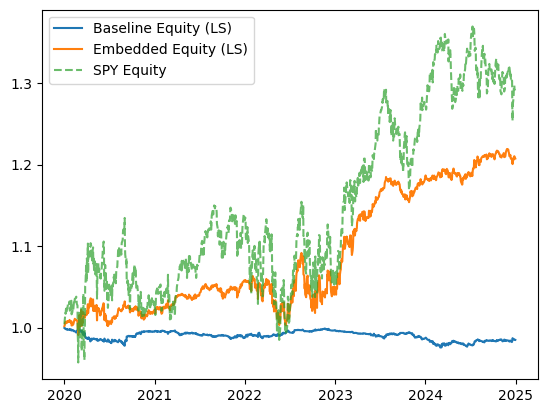

In [56]:
import matplotlib.pyplot as plt
plt.plot(out_ls["baseline"]["equity"], label="Baseline Equity (LS)")
plt.plot(out_ls["embedded"]["equity"], label="Embedded Equity (LS)")
plt.plot(out_ls["spy_eq"], label="SPY Equity", linestyle="--", alpha=0.7)
plt.legend()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(out_ls["baseline"]["equity"], label="Baseline Equity")
plt.plot(out_ls["embedded"]["equity"], label="Embedded Equity")
plt.plot(out_ls["spy_eq"], label="SPY Equity", linestyle="--", alpha=0.7)
plt.legend()
plt.title("Equity Curves")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.show()

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(out_ls["baseline"]["gross"], label="Baseline gross returns")
plt.plot(out_ls["embedded"]["gross"], label="Embedded gross returns")
plt.legend()
plt.title("Gross returns")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.show()

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(out_ls["baseline"]["net"], label="Baseline net returns")
plt.plot(out_ls["embedded"]["net"], label="Embedded net returns")
plt.legend()
plt.title("Equity Curves")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.show()

In [ ]:
print("Baseline sharpe - gross returns:", perf_summary(out_ls["baseline"]["gross"])["Sharpe"])
print("Embedded sharpe - gross returns:", perf_summary(out_ls["embedded"]["gross"])["Sharpe"])

print("Baseline sharpe - net returns:", perf_summary(out_ls["baseline"]["net"])["Sharpe"])
print("Embedded sharpe - net returns:", perf_summary(out_ls["embedded"]["net"])["Sharpe"])

In [ ]:
print("Baseline maxDD - gross returns:", perf_summary(out_ls["baseline"]["gross"])["MaxDD"])
print("Embedded maxDD - gross returns:", perf_summary(out_ls["embedded"]["gross"])["MaxDD"])

print("Baseline maxDD - net returns:", perf_summary(out_ls["baseline"]["net"])["MaxDD"])
print("Embedded maxDD - net returns:", perf_summary(out_ls["embedded"]["net"])["MaxDD"])

In [ ]:
perf_summary(out_ls["baseline"]["gross"])

In [ ]:
perf_summary(out_ls["embedded"]["gross"])

In [ ]:
perf_summary(out_ls["baseline"]["net"])

In [ ]:
perf_summary(out_ls["embedded"]["net"])

In [ ]:

alpha_e, beta_e, t_e = alpha_beta(out_ls["embedded"]["net"], out_ls["spy_rets"])
alpha_b, beta_b, t_b = alpha_beta(out_ls["baseline"]["net"], out_ls["spy_rets"])

print("Embedded alpha/day, beta, t(alpha):", alpha_e, beta_e, t_e)
print("Baseline alpha/day, beta, t(alpha):", alpha_b, beta_b, t_b)
print("Embedded alpha/yr approx:", alpha_e * 252)


In [ ]:
# Holdings on the last backtest day (includes longs + shorts)
day = out_ls["embedded"]["holdings"]["date"].max()
(out_ls["embedded"]["holdings"]
 .query("date == @day")
 .sort_values("abs_weight", ascending=False)
 .head(20))


In [ ]:
alpha_roll, beta_roll = rolling_alpha_beta(out_ls["embedded"]["net"], out_ls["spy_rets"], window=252)

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(alpha_roll, label="Rolling Alpha (yr)")
plt.axhline(0, color="black", linestyle="--", alpha=0.7)
plt.title("Rolling Alpha (1-year window)")  
plt.xlabel("Date")
plt.show()  

In [ ]:
plt.Figure(figsize=(10,6))
plt.plot(beta_roll, label="Rolling Beta")  
plt.axhline(1, color="black", linestyle="--", alpha=0.7)
plt.title("Rolling Beta (1-year window)")
plt.xlabel("Date")
plt.show()

## Stress tests (Long-Short)

This section assumes you already ran:

```python
out_ls = run_experiment(..., weight_mode="long_short", gross_long=..., gross_short=...)
```

and uses `out_ls` directly where possible.

We run 4 tests:
1. Cost + slippage sweep (fast, uses stored gross + turnover)
2. Feature ablation (retrain; slower)
3. Placebo: shuffle Y in training (retrain; should kill edge)
4. Monte Carlo (50k bootstrap paths on embedded net returns)


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Helpers: metrics & recompute net under alternative cost assumptions
# ----------------------------

def perf_summary_with_turnover(bt_out, which="net", freq=252):
    'Compute CAGR/Sharpe/MaxDD, plus avg turnover and final equity.'
    r = bt_out[which].dropna()
    if len(r) < 10:
        return {}
    mu = r.mean()
    sd = r.std(ddof=0)
    sharpe = (mu / (sd + 1e-12)) * np.sqrt(freq)

    eq = (1 + r).cumprod()
    peak = eq.cummax()
    dd = eq / peak - 1
    mdd = dd.min()

    cagr = eq.iloc[-1] ** (freq / len(r)) - 1

    avg_to = float(bt_out.get("turnover", pd.Series(index=r.index, data=np.nan)).reindex(r.index).mean())
    return {
        "CAGR": float(cagr),
        "Sharpe": float(sharpe),
        "MaxDD": float(mdd),
        "AvgTurnover": float(avg_to) if np.isfinite(avg_to) else np.nan,
        "FinalEquity": float(eq.iloc[-1]),
        "N": int(len(r)),
    }

def recompute_net_from_gross_and_turnover(bt_out, tc_bps_per_side, slip_bps):
    'Recompute net returns and equity for new costs WITHOUT rerunning the model.'
    gross = bt_out["gross"].copy()
    turnover = bt_out["turnover"].reindex(gross.index).fillna(0.0)

    cost_rate = (tc_bps_per_side + slip_bps) / 1e4
    net = gross - cost_rate * turnover
    eq = (1 + net.fillna(0)).cumprod()

    out = dict(bt_out)  # shallow copy
    out["net_recosted"] = net
    out["equity_recosted"] = eq
    return out

# Sanity: confirm out_ls exists
assert "out_ls" in globals(), "Run your main experiment first so out_ls exists."
print("Using universe size:", len(out_ls["universe"]))
print("Feature names:", out_ls["feat_names"])


In [ ]:

# ----------------------------
# 1) Cost + slippage sweep (FAST)
# ----------------------------

COST_GRID = [
    (5.0, 2.0),   # tc, slip (bps)
    (10.0, 5.0),
    (20.0, 10.0),
    (30.0, 15.0),
    (60.0, 30.0),
]

rows = []
for tc, slip in COST_GRID:
    base_rc = recompute_net_from_gross_and_turnover(out_ls["baseline"], tc, slip)
    emb_rc  = recompute_net_from_gross_and_turnover(out_ls["embedded"], tc, slip)

    s_base = perf_summary_with_turnover(base_rc, which="net_recosted")
    s_emb  = perf_summary_with_turnover(emb_rc,  which="net_recosted")

    rows.append({
        "tc_bps_per_side": tc,
        "slip_bps": slip,
        "total_bps": tc + slip,
        "baseline_sharpe": s_base.get("Sharpe", np.nan),
        "embedded_sharpe": s_emb.get("Sharpe", np.nan),
        "baseline_cagr": s_base.get("CAGR", np.nan),
        "embedded_cagr": s_emb.get("CAGR", np.nan),
        "baseline_maxdd": s_base.get("MaxDD", np.nan),
        "embedded_maxdd": s_emb.get("MaxDD", np.nan),
        "baseline_final_eq": s_base.get("FinalEquity", np.nan),
        "embedded_final_eq": s_emb.get("FinalEquity", np.nan),
        "avg_turnover_baseline": s_base.get("AvgTurnover", np.nan),
        "avg_turnover_embedded": s_emb.get("AvgTurnover", np.nan),
    })

cost_df = pd.DataFrame(rows).sort_values("total_bps")
display(cost_df)

# Plot: Sharpe vs total cost (two lines)
plt.figure(figsize=(10,6))
plt.plot(cost_df["total_bps"], cost_df["baseline_sharpe"], marker="o", label="Baseline (net) Sharpe")
plt.plot(cost_df["total_bps"], cost_df["embedded_sharpe"], marker="o", label="Embedded (net) Sharpe")
plt.axhline(0.0, linewidth=1)
plt.title("Cost sweep: Sharpe(net) vs total cost (bps)")
plt.xlabel("Total cost (tc + slippage) in bps")
plt.ylabel("Sharpe (annualized)")
plt.legend()
plt.show()

# Optional: CAGR vs cost
plt.figure(figsize=(10,6))
plt.plot(cost_df["total_bps"], cost_df["baseline_cagr"], marker="o", label="Baseline (net) CAGR")
plt.plot(cost_df["total_bps"], cost_df["embedded_cagr"], marker="o", label="Embedded (net) CAGR")
plt.axhline(0.0, linewidth=1)
plt.title("Cost sweep: CAGR(net) vs total cost (bps)")
plt.xlabel("Total cost (tc + slippage) in bps")
plt.ylabel("CAGR (annualized)")
plt.legend()
plt.show()


In [ ]:

# ----------------------------
# 2) Feature ablation (RETRAIN; SLOWER)
# ----------------------------
# Idea: remove one feature at a time, retrain embedded model, test on the same splits.

ABL_EPOCHS = 3  # lower this to go faster

ABL_TICKERS = out_ls["universe"]
ABL_TOP_N = len(ABL_TICKERS)

def run_embedded_only_with_custom_feats(
    feats_override, y_override, *,
    tickers, seq_len=20,
    train_end="2017-12-31", val_end="2019-12-31",
    gamma=0.0, max_w=0.02,
    tc_bps=10.0, slip_bps=5.0,
    epochs=3, lr=1e-3, lam_embedded=0.8,
    weight_mode="long_short", gross_long=1.0, gross_short=1.0
):
    batches_all, feat_names = build_day_batches(feats_override, y_override, tickers=tickers, seq_len=seq_len)

    train_end_dt = pd.to_datetime(train_end)
    val_end_dt = pd.to_datetime(val_end)

    batches_train = [b for b in batches_all if pd.to_datetime(b[0]) <= train_end_dt]
    batches_val   = [b for b in batches_all if train_end_dt < pd.to_datetime(b[0]) <= val_end_dt]
    batches_test  = [b for b in batches_all if pd.to_datetime(b[0]) > val_end_dt]

    n_features = len(feat_names)

    model_emb = train_model(
        batches_train, batches_val, n_features,
        lam=lam_embedded, k_turn=0.05, k_conc=0.05,
        gamma=gamma, max_w=max_w,
        lr=lr, epochs=epochs,
        weight_mode=weight_mode, gross_long=gross_long, gross_short=gross_short,
    )

    bt_emb = backtest_batches(
        model_emb, batches_test,
        tc_bps_per_side=tc_bps, slip_bps=slip_bps,
        gamma=gamma, max_w=max_w,
        weight_mode=weight_mode, gross_long=gross_long, gross_short=gross_short
    )
    return bt_emb, feat_names

# Re-download data (yfinance variability warning). If you want perfect reproducibility, cache data locally.
data = download_ohlcv(list(dict.fromkeys(ABL_TICKERS + ["SPY"])), start="2010-01-01", end=None, auto_adjust=False)
feats_full, y_full = make_features(data)

feat_list = list(feats_full.keys())

results = []

# Full embedded model first
bt_full, _ = run_embedded_only_with_custom_feats(
    feats_full, y_full,
    tickers=ABL_TICKERS,
    epochs=ABL_EPOCHS,
    weight_mode="long_short", gross_long=1.0, gross_short=1.0
)
s_full = perf_summary_with_turnover(bt_full, which="net")
results.append({"dropped_feature": "(none)", **s_full})

# Drop one at a time
for drop in feat_list:
    feats_abl = {k:v for k,v in feats_full.items() if k != drop}
    bt_abl, _ = run_embedded_only_with_custom_feats(
        feats_abl, y_full,
        tickers=ABL_TICKERS,
        epochs=ABL_EPOCHS,
        weight_mode="long_short", gross_long=1.0, gross_short=1.0
    )
    s = perf_summary_with_turnover(bt_abl, which="net")
    results.append({"dropped_feature": drop, **s})

abl_df = pd.DataFrame(results).sort_values("Sharpe", ascending=False)
display(abl_df)

# Plot: Sharpe by ablation
plt.figure(figsize=(10,6))
tmp = abl_df.sort_values("Sharpe")
plt.barh(tmp["dropped_feature"], tmp["Sharpe"])
plt.title("Feature ablation: embedded Sharpe(net) after dropping one feature")
plt.xlabel("Sharpe (annualized)")
plt.ylabel("Dropped feature")
plt.show()


In [ ]:

# ----------------------------
# 3) Placebo: shuffle Y in TRAINING (RETRAIN; should kill edge)
# ----------------------------
# Shuffle labels within each day across tickers for train+val only, then evaluate on real test.

PLACEBO_EPOCHS = 3
PLACEBO_TICKERS = out_ls["universe"]

data_p = download_ohlcv(list(dict.fromkeys(PLACEBO_TICKERS + ["SPY"])), start="2010-01-01", end=None, auto_adjust=False)
feats_p, y_p = make_features(data_p)

batches_all, feat_names = build_day_batches(feats_p, y_p, tickers=PLACEBO_TICKERS, seq_len=20)

train_end_dt = pd.to_datetime("2017-12-31")
val_end_dt = pd.to_datetime("2019-12-31")
batches_train = [b for b in batches_all if pd.to_datetime(b[0]) <= train_end_dt]
batches_val   = [b for b in batches_all if train_end_dt < pd.to_datetime(b[0]) <= val_end_dt]
batches_test  = [b for b in batches_all if pd.to_datetime(b[0]) > val_end_dt]

def shuffle_batch_Y(batches, seed):
    rng = np.random.default_rng(seed)
    out = []
    for (dt, X, Y) in batches:
        Y2 = Y.copy()
        rng.shuffle(Y2)  # permutes across tickers within the day
        out.append((dt, X, Y2))
    return out

batches_train_shuf = shuffle_batch_Y(batches_train, seed=1)
batches_val_shuf   = shuffle_batch_Y(batches_val,   seed=2)

n_features = len(feat_names)

print("Training placebo baseline (MSE only) on shuffled labels...")
model_base_p = train_model(
    batches_train_shuf, batches_val_shuf, n_features,
    lam=0.0, k_turn=0.0, k_conc=0.0,
    gamma=0.0, max_w=0.02,
    lr=1e-3, epochs=PLACEBO_EPOCHS,
    weight_mode="long_short", gross_long=1.0, gross_short=1.0
)

print("\nTraining placebo embedded on shuffled labels...")
model_emb_p = train_model(
    batches_train_shuf, batches_val_shuf, n_features,
    lam=0.8, k_turn=0.05, k_conc=0.05,
    gamma=0.0, max_w=0.02,
    lr=1e-3, epochs=PLACEBO_EPOCHS,
    weight_mode="long_short", gross_long=1.0, gross_short=1.0
)

bt_base_p = backtest_batches(
    model_base_p, batches_test,
    tc_bps_per_side=10.0, slip_bps=5.0,
    gamma=0.0, max_w=0.02,
    weight_mode="long_short", gross_long=1.0, gross_short=1.0
)
bt_emb_p = backtest_batches(
    model_emb_p, batches_test,
    tc_bps_per_side=10.0, slip_bps=5.0,
    gamma=0.0, max_w=0.02,
    weight_mode="long_short", gross_long=1.0, gross_short=1.0
)

print("\nPlacebo results (should be near 0 or negative after costs):")
print("Baseline placebo:", perf_summary_with_turnover(bt_base_p, "net"))
print("Embedded placebo:", perf_summary_with_turnover(bt_emb_p, "net"))

# Plot: placebo equity curves
plt.figure(figsize=(10,6))
plt.plot(bt_base_p["equity"], label="Baseline placebo equity")
plt.plot(bt_emb_p["equity"], label="Embedded placebo equity")
plt.title("Placebo (shuffled Y in training): equity curves on real test")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.legend()
plt.show()


In [ ]:

# ----------------------------
# 4) Monte Carlo bootstrap (50k sims) on embedded NET returns
# ----------------------------
# Resampling Monte Carlo on realized daily returns.
# Note: IID bootstrap is fast but ignores volatility clustering; block bootstrap is more realistic.

MC_SIMS = 50_000
CHUNK = 1000  # adjust for memory/speed

r = out_ls["embedded"]["net"].dropna().values.astype(np.float64)
T = len(r)
freq = 252

if T < 50:
    raise RuntimeError("Not enough returns for Monte Carlo.")

def mc_metrics_chunk(r, n_sims, rng):
    idx = rng.integers(0, len(r), size=(n_sims, len(r)))
    R = r[idx]  # [n_sims, T]

    mu = R.mean(axis=1)
    sd = R.std(axis=1, ddof=0)
    sharpe = (mu / (sd + 1e-12)) * np.sqrt(freq)

    EQ = np.cumprod(1.0 + R, axis=1)
    final_eq = EQ[:, -1]
    cagr = final_eq ** (freq / T) - 1.0

    peak = np.maximum.accumulate(EQ, axis=1)
    dd = EQ / (peak + 1e-12) - 1.0
    mdd = dd.min(axis=1)

    return sharpe, cagr, mdd

rng = np.random.default_rng(12345)
sharpes = np.empty(MC_SIMS, dtype=np.float64)
cagrs   = np.empty(MC_SIMS, dtype=np.float64)
mdds    = np.empty(MC_SIMS, dtype=np.float64)

pos = 0
while pos < MC_SIMS:
    n = min(CHUNK, MC_SIMS - pos)
    s, c, m = mc_metrics_chunk(r, n, rng)
    sharpes[pos:pos+n] = s
    cagrs[pos:pos+n]   = c
    mdds[pos:pos+n]    = m
    pos += n

def summarize_mc(arr, name):
    p = np.percentile(arr, [1, 5, 25, 50, 75, 95, 99])
    return {
        f"{name}_p01": p[0],
        f"{name}_p05": p[1],
        f"{name}_p25": p[2],
        f"{name}_p50": p[3],
        f"{name}_p75": p[4],
        f"{name}_p95": p[5],
        f"{name}_p99": p[6],
        f"{name}_mean": float(arr.mean()),
        f"{name}_std": float(arr.std(ddof=0)),
    }

mc_summary = {}
mc_summary.update(summarize_mc(cagrs, "CAGR"))
mc_summary.update(summarize_mc(sharpes, "Sharpe"))
mc_summary.update(summarize_mc(mdds, "MaxDD"))

mc_summary["P(CAGR<0)"] = float((cagrs < 0).mean())
mc_summary["P(Sharpe<0)"] = float((sharpes < 0).mean())
mc_summary["P(MaxDD<-0.3)"] = float((mdds < -0.3).mean())

display(pd.DataFrame([mc_summary]).T.rename(columns={0:"value"}))

# Plot: histogram of CAGR
plt.figure(figsize=(10,6))
plt.hist(cagrs, bins=60, alpha=0.9)
real_cagr = perf_summary_with_turnover(out_ls["embedded"], "net").get("CAGR", np.nan)
plt.axvline(real_cagr, linewidth=2, label=f"Real CAGR: {real_cagr:.3f}")
plt.title("Monte Carlo (50k): bootstrap distribution of CAGR (embedded net)")
plt.xlabel("CAGR")
plt.ylabel("Count")
plt.legend()
plt.show()


## MonteVarlo simulation

In [ ]:

# ============================================================
# (NEW) Freeze model + Market Monte Carlo (simulate the market)
# Uses the FINAL trained model (no retraining)
# ============================================================

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def save_frozen_model(path="frozen_embedded_longshort.pt", which="embedded"):
    """
    Save the final trained model from the most recent run_experiment().
    This respects your workflow: run_experiment(...) -> out_ls exists,
    and we also expose LAST_MODEL_EMB/LAST_MODEL_BASE from inside run_experiment.
    """
    if which not in ("embedded","baseline"):
        raise ValueError("which must be 'embedded' or 'baseline'")

    model = LAST_MODEL_EMB if which=="embedded" else LAST_MODEL_BASE
    if model is None:
        raise RuntimeError("No trained model found. Run run_experiment(...) first.")

    meta = dict(
        which=which,
        feat_names=LAST_FEAT_NAMES,
        n_features=len(LAST_FEAT_NAMES),
        hidden=64,  # must match train_model() architecture
        seq_len=LAST_RUN_CFG["seq_len"],
        gamma=LAST_RUN_CFG["gamma"],
        max_w=LAST_RUN_CFG["max_w"],
        weight_mode=LAST_RUN_CFG["weight_mode"],
        gross_long=LAST_RUN_CFG["gross_long"],
        gross_short=LAST_RUN_CFG["gross_short"],
    )

    torch.save({"state_dict": model.state_dict(), "meta": meta}, path)
    print(f"Saved frozen {which} model to: {path}")
    return path

def load_frozen_model(path="frozen_embedded_longshort.pt", device=DEVICE):
    payload = torch.load(path, map_location=device)
    meta = payload["meta"]
    model = LSTMAlpha(n_features=meta["n_features"], hidden=meta["hidden"]).to(device)
    model.load_state_dict(payload["state_dict"])
    model.eval()
    print(f"Loaded frozen model from: {path}")
    return model, meta


# ----------------------------
# Market simulator (factor model + bull/bear regimes)
# ----------------------------
def calibrate_factor_model(data, tickers, k=3):
    """
    Calibrate a simple k-factor model from historical close-to-close log returns.
    This gives realistic cross-sectional correlation (important for long/short).
    """
    close = data["Close"][tickers].dropna()
    rets = np.log(close).diff().dropna()  # log returns, shape [T, N]
    R = rets.values
    mu = R.mean(axis=0)
    Rc = R - mu

    cov = np.cov(Rc, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]

    W = eigvecs[:, :k]
    S = np.diag(np.sqrt(np.maximum(eigvals[:k], 1e-12)))
    betas = W @ S  # [N, k]

    B = betas
    BtB_inv = np.linalg.pinv(B.T @ B)
    F = (BtB_inv @ B.T @ Rc.T).T  # factor returns [T, k]

    factor_mu = F.mean(axis=0)
    factor_cov = np.cov(F, rowvar=False)

    R_hat = F @ B.T
    E = Rc - R_hat
    resid_std = E.std(axis=0, ddof=0)

    calib = dict(
        tickers=tickers,
        start_prices=close.iloc[0].values,
        dates=close.index,
        betas=betas,
        factor_mu=factor_mu,
        factor_cov=factor_cov,
        resid_std=resid_std,
    )
    return calib

def simulate_ohlcv_factor_regime(
    calib,
    dates,
    seed=0,
    bull_mu_shift=0.0003,
    bear_mu_shift=-0.0008,
    bull_vol_mult=1.0,
    bear_vol_mult=1.6,
    p_switch=0.01,
    gap_frac=0.25,
    vol_logn_mu=12.0,
    vol_logn_sigma=0.7,
):
    """
    Produce a dict with keys Open, Close, Volume, High, Low matching your pipeline.
    """
    rng = np.random.default_rng(seed)
    tickers = calib["tickers"]
    n = len(tickers)
    T = len(dates)

    B = calib["betas"]
    f_mu = calib["factor_mu"]
    f_cov = calib["factor_cov"]
    eps_std = calib["resid_std"]
    Lf = np.linalg.cholesky(f_cov + 1e-12*np.eye(f_cov.shape[0]))

    reg = np.zeros(T, dtype=int)
    for t in range(1, T):
        if rng.random() < p_switch:
            reg[t] = 1 - reg[t-1]
        else:
            reg[t] = reg[t-1]

    open_px = np.zeros((T, n))
    close_px = np.zeros((T, n))
    volu = np.zeros((T, n))

    close_prev = calib["start_prices"].copy()

    for t in range(T):
        is_bear = (reg[t] == 1)
        mu_shift = bear_mu_shift if is_bear else bull_mu_shift
        vol_mult = bear_vol_mult if is_bear else bull_vol_mult

        zf = rng.standard_normal(Lf.shape[0])
        f_t = f_mu + (Lf @ zf) * vol_mult

        ze = rng.standard_normal(n)
        eps_t = ze * eps_std * vol_mult

        r_total = (B @ f_t) + eps_t + mu_shift  # log return close-to-close

        # Split into overnight gap + intraday move
        gap = rng.standard_normal(n) * (np.std(r_total) + 1e-6) * gap_frac
        intraday = r_total - gap

        open_t = close_prev * np.exp(gap)
        close_t = open_t * np.exp(intraday)

        # volume: lognormal base * (1 + activity)
        baseV = rng.lognormal(mean=vol_logn_mu, sigma=vol_logn_sigma, size=n)
        vol_t = baseV * (1.0 + 10.0*np.abs(intraday))

        open_px[t] = open_t
        close_px[t] = close_t
        volu[t] = vol_t
        close_prev = close_t

    df_open = pd.DataFrame(open_px, index=dates, columns=tickers)
    df_close = pd.DataFrame(close_px, index=dates, columns=tickers)
    df_vol = pd.DataFrame(volu, index=dates, columns=tickers)

    df_high = pd.DataFrame(np.maximum(df_open, df_close), index=dates, columns=tickers)
    df_low  = pd.DataFrame(np.minimum(df_open, df_close), index=dates, columns=tickers)

    return {"Open": df_open, "Close": df_close, "Volume": df_vol, "High": df_high, "Low": df_low, "regime": reg}


# ----------------------------
# Run frozen model on a simulated market
# ----------------------------
def backtest_frozen_on_simulated_market(
    model_frozen,
    meta,
    data_sim,
    tickers,
    tc_bps=10.0,
    slip_bps=5.0,
):
    feats, y = make_features(data_sim)
    batches_all, feat_names = build_day_batches(feats, y, tickers=tickers, seq_len=meta["seq_len"])

    bt = backtest_batches(
        model_frozen,
        batches_all,
        tc_bps_per_side=tc_bps,
        slip_bps=slip_bps,
        gamma=meta["gamma"],
        max_w=meta["max_w"],
        weight_mode=meta["weight_mode"],
        gross_long=meta["gross_long"],
        gross_short=meta["gross_short"],
    )
    return bt


def market_monte_carlo(
    model_frozen,
    meta,
    calib,
    n_sims=200,
    seed0=123,
    tc_bps=10.0,
    slip_bps=5.0,
    sim_params=None,
):
    """
    Monte Carlo market simulation with the frozen final model.
    Returns:
      eq_df: [date x sim] equity paths
      met_df: per-sim performance summary table
    """
    if sim_params is None:
        sim_params = {}

    dates = calib["dates"]
    tickers = calib["tickers"]

    equities = []
    rows = []

    for s in range(n_sims):
        data_sim = simulate_ohlcv_factor_regime(
            calib,
            dates=dates,
            seed=seed0 + s,
            **sim_params
        )
        bt = backtest_frozen_on_simulated_market(
            model_frozen, meta,
            data_sim=data_sim,
            tickers=tickers,
            tc_bps=tc_bps,
            slip_bps=slip_bps,
        )

        eq = bt["equity"].copy()
        equities.append(eq.rename(f"sim_{s}"))

        summ = perf_summary(bt["net"])
        summ["FinalEquity"] = float(eq.iloc[-1])
        rows.append(summ)

    eq_df = pd.concat(equities, axis=1)
    met_df = pd.DataFrame(rows)
    return eq_df, met_df


def plot_fanchart_and_variance(eq_df, title="Monte Carlo Equity Fan Chart"):
    eq = eq_df.ffill().dropna(how="all")
    mean = eq.mean(axis=1)
    p05 = eq.quantile(0.05, axis=1)
    p25 = eq.quantile(0.25, axis=1)
    p75 = eq.quantile(0.75, axis=1)
    p95 = eq.quantile(0.95, axis=1)
    var = eq.var(axis=1)

    plt.figure(figsize=(10,6))
    plt.plot(mean, label="Mean equity")
    plt.plot(p05, linestyle="--", alpha=0.7, label="p05")
    plt.plot(p95, linestyle="--", alpha=0.7, label="p95")
    plt.plot(p25, linestyle=":", alpha=0.7, label="p25")
    plt.plot(p75, linestyle=":", alpha=0.7, label="p75")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10,6))
    plt.plot(var)
    plt.title("Variance of equity across simulations (robustness over time)")
    plt.xlabel("Date")
    plt.ylabel("Var(Equity)")
    plt.show()


def plot_metric_histograms(met_df, real_metrics=None):
    for col in ["CAGR", "Sharpe", "MaxDD", "FinalEquity"]:
        if col not in met_df.columns:
            continue
        plt.figure(figsize=(10,6))
        plt.hist(met_df[col].dropna().values, bins=50)
        if real_metrics is not None and col in real_metrics:
            plt.axvline(real_metrics[col])
        plt.title(f"Distribution of {col} across market simulations")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

    if "CAGR" in met_df.columns:
        print("P(CAGR < 0):", float((met_df["CAGR"] < 0).mean()))
    if "Sharpe" in met_df.columns:
        print("P(Sharpe < 0):", float((met_df["Sharpe"] < 0).mean()))
    if "MaxDD" in met_df.columns:
        print("P(MaxDD < -0.30):", float((met_df["MaxDD"] < -0.30).mean()))


In [ ]:

# ============================================================
# (NEW) How to run market Monte Carlo with your final model
# ============================================================

from IPython.display import display

# 1) Save the final trained embedded model from your last run_experiment()
frozen_path = save_frozen_model(path="frozen_embedded_longshort.pt", which="embedded")

# 2) Load it (to prove we are using the frozen final model)
model_frozen, meta_frozen = load_frozen_model(frozen_path, device=DEVICE)

# 3) Calibrate the market simulator from historical data for the SAME universe
tickers_sim = out_ls["universe"]
data_hist = download_ohlcv(tickers_sim, start="2010-01-01", end=None, auto_adjust=False)
calib = calibrate_factor_model(data_hist, tickers=tickers_sim, k=3)

# 4) Run market Monte Carlo (start with 200 sims; increase if you want)
#    Note: true "50k market sims" is usually too heavy; if you insist, raise n_sims carefully.
eq_mc, met_mc = market_monte_carlo(
    model_frozen,
    meta_frozen,
    calib,
    n_sims=200,
    seed0=123,
    tc_bps=out_ls.get("tc_bps", 10.0) if isinstance(out_ls, dict) else 10.0,
    slip_bps=out_ls.get("slip_bps", 5.0) if isinstance(out_ls, dict) else 5.0,
    sim_params=dict(
        # You can stress the market here:
        # bear_mu_shift=-0.0012,
        # p_switch=0.02,
        # bear_vol_mult=2.0,
    ),
)

# 5) Plot robustness over time: fan chart + variance curve
plot_fanchart_and_variance(eq_mc, title="Frozen embedded model: MC market equity fan chart")

# 6) Compare distributions to the REAL backtest metrics from your historical test set
real = perf_summary(out_ls["embedded"]["net"])
real["FinalEquity"] = float(out_ls["embedded"]["equity"].iloc[-1])

plot_metric_histograms(met_mc, real_metrics=real)

print("Real (historical) metrics:", real)
print("MC metrics summary (mean/median):")
display(met_mc.describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]))
